# Exotics in Isolation

Round 4 manual challenge. Advisor's first lesson:

> **Look at the exotic payoff in isolation first. Then ask what happens when you layer vanilla calls or puts alongside it.**

This notebook does the **first half**: for each exotic, plot the terminal payoff as a function of state and ask **what makes it different from a vanilla**. The pure-vanilla intuition is

$$\text{payoff} = f(S_T)$$

i.e., one number per path: the spot at expiry. Exotics break this. Each one will surface a *new axis* of risk that vanilla intuition cannot see.

Underlying: `AETHER_CRYSTAL`. GBM with $\sigma=251\%$, $r=0$, $S_0=49.975$. Expiries 14d (2-week) and 21d (3-week); time grid 4 ticks/day.

## Setup

Two pieces of state used throughout:

1. **`MARKET`** — single source of truth for every contract spec. Each entry holds the contract name, type, strike, barrier (if any), `binary_put_payout` (digital contracts only), expiry tick, decision tick (chooser only), and the live bid/ask off the screenshot. **Every later cell pulls its numbers from here.**
2. **Time-grid aliases** — readable names for `mc_engine`'s tick constants so we never have to remember whether `T1_STEPS` means "two-week expiry" or "chooser decision" (it's both).

In [157]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from mc_engine import (
    simulate_paths, S0, DT, T1_STEPS, T2_STEPS,
    call_payoff, put_payoff,
    binary_put_payoff, knockout_put_payoff, chooser_payoff,
    bs_call, bs_put, mc_price,
)

# --- Time-grid: readable aliases for the engine's tick counts ---
INITIAL_SPOT             = S0          # 49.975
YEAR_FRACTION_PER_TICK   = DT          # 1 / (252 * 4)
TICK_AT_2W_EXPIRY        = T1_STEPS    # 14d * 4 = 56 ticks  (also the chooser decision tick)
TICK_AT_3W_EXPIRY        = T2_STEPS    # 21d * 4 = 84 ticks
TICK_AT_CHOOSER_DECISION = T1_STEPS    # same number as 2w expiry, but conceptually different
NUM_PATHS                = 1_000_000
RANDOM_SEED              = 7

# --- MARKET: single source of truth for every contract on the platform ---
MARKET = {
    'AC_50_C':   {'kind': 'call',       'strike': 50, 'expiry_tick': TICK_AT_3W_EXPIRY,
                  'bid': 12.00,  'ask': 12.05},
    'AC_50_P':   {'kind': 'put',        'strike': 50, 'expiry_tick': TICK_AT_3W_EXPIRY,
                  'bid': 12.00,  'ask': 12.05},
    'AC_35_P':   {'kind': 'put',        'strike': 35, 'expiry_tick': TICK_AT_3W_EXPIRY,
                  'bid':  4.33,  'ask':  4.35},
    'AC_40_P':   {'kind': 'put',        'strike': 40, 'expiry_tick': TICK_AT_3W_EXPIRY,
                  'bid':  6.50,  'ask':  6.55},
    'AC_45_P':   {'kind': 'put',        'strike': 45, 'expiry_tick': TICK_AT_3W_EXPIRY,
                  'bid':  9.05,  'ask':  9.10},
    'AC_60_C':   {'kind': 'call',       'strike': 60, 'expiry_tick': TICK_AT_3W_EXPIRY,
                  'bid':  8.80,  'ask':  8.85},
    'AC_50_C_2': {'kind': 'call',       'strike': 50, 'expiry_tick': TICK_AT_2W_EXPIRY,
                  'bid':  9.70,  'ask':  9.75},
    'AC_50_P_2': {'kind': 'put',        'strike': 50, 'expiry_tick': TICK_AT_2W_EXPIRY,
                  'bid':  9.70,  'ask':  9.75},
    'AC_40_BP':  {'kind': 'binary_put', 'strike': 40, 'expiry_tick': TICK_AT_3W_EXPIRY,
                  'binary_put_payout': 10.0, 'bid': 5.00, 'ask': 5.10},
    # AC_45_KO: Strike 45, Barrier 35 (confirmed from manual.md)
    'AC_45_KO':  {'kind': 'ko_put',     'strike': 45, 'barrier': 35, 'expiry_tick': TICK_AT_3W_EXPIRY,
                  'bid': 0.15, 'ask': 0.175},
    'AC':        {'kind': 'underlying', 'strike': None, 'expiry_tick': TICK_AT_3W_EXPIRY,
                  'bid': 49.975, 'ask': 50.025},
    'AC_50_CO':  {'kind': 'chooser',    'strike': 50, 'expiry_tick': TICK_AT_3W_EXPIRY,
                  'decision_tick': TICK_AT_CHOOSER_DECISION, 'bid': 22.20, 'ask': 22.30},
}

# Simulate one batch of GBM paths; reuse for every plot
paths = simulate_paths(NUM_PATHS, n_steps=TICK_AT_3W_EXPIRY, seed=RANDOM_SEED)

# Convenient slices off those paths (intuitive names, no indexing in later cells)
spot_at_3w_expiry        = paths[:, TICK_AT_3W_EXPIRY]
spot_at_2w_expiry        = paths[:, TICK_AT_2W_EXPIRY]
spot_at_chooser_decision = paths[:, TICK_AT_CHOOSER_DECISION]
min_spot_over_path       = paths.min(axis=1)

print(f'paths shape: {paths.shape}')
print(f'E[S_T] over paths: {spot_at_3w_expiry.mean():.3f}  (martingale check, target ~ S0={INITIAL_SPOT})')

paths shape: (1000000, 85)
E[S_T] over paths: 49.885  (martingale check, target ~ S0=49.975)


## 1. Vanilla baseline — one axis is enough

A vanilla call/put depends only on `S_T`. Plot payoff vs spot at expiry. Hockey stick. No surprises. This is the intuition that exotics will break.

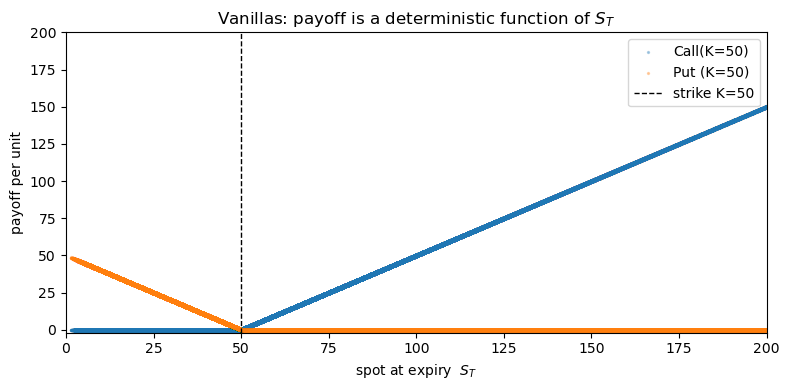

In [158]:
vanilla_call = MARKET['AC_50_C']
vanilla_put  = MARKET['AC_50_P']
atm_strike   = vanilla_call['strike']

vanilla_call_payoff_per_unit = call_payoff(spot_at_3w_expiry, atm_strike)
vanilla_put_payoff_per_unit  = put_payoff (spot_at_3w_expiry, atm_strike)

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(spot_at_3w_expiry, vanilla_call_payoff_per_unit, s=2, alpha=0.3,
           label=f'Call(K={atm_strike})')
ax.scatter(spot_at_3w_expiry, vanilla_put_payoff_per_unit,  s=2, alpha=0.3,
           label=f'Put (K={atm_strike})')
ax.axvline(atm_strike, color='k', ls='--', lw=1, label=f'strike K={atm_strike}')
ax.set(xlabel='spot at expiry  $S_T$', ylabel='payoff per unit',
       title='Vanillas: payoff is a deterministic function of $S_T$',
       xlim=(0, 200), ylim=(-2, 200))
ax.legend(); plt.tight_layout(); plt.show()

In [159]:
# --- Step 2: Fair vs market for every vanilla (puts + calls, both expiries) ---
# Quick audit so the QP at the end has accurate edges per instrument.
# All edges measured under the manual's sigma=2.51, the same sigma the scoring
# engine simulates.  Long edge = fair - ask;  short edge = bid - fair.

vanilla_contracts = [
    'AC_50_C', 'AC_50_P',
    'AC_35_P', 'AC_40_P', 'AC_45_P',
    'AC_60_C',
    'AC_50_C_2', 'AC_50_P_2',
]

print(f"{'name':12s} {'kind':5s} {'K':>4s} {'T(d)':>5s}  "
      f"{'bid':>6s} {'ask':>6s} {'mid':>7s} {'fair':>7s}  "
      f"{'long_edge':>10s}  {'short_edge':>11s}")
for name in vanilla_contracts:
    spec = MARKET[name]
    K = spec['strike']
    expiry_tick = spec['expiry_tick']
    days = round(expiry_tick * YEAR_FRACTION_PER_TICK * 252)
    spot_at_T = paths[:, expiry_tick]
    if spec['kind'] == 'call':
        payoff_per_unit = call_payoff(spot_at_T, K)
    else:
        payoff_per_unit = put_payoff(spot_at_T, K)
    fair = payoff_per_unit.mean()
    bid, ask = spec['bid'], spec['ask']
    mid = 0.5 * (bid + ask)
    long_edge  = fair - ask        # buy at ask -> profit if fair > ask
    short_edge = bid  - fair       # sell at bid -> profit if bid  > fair
    print(f"{name:12s} {spec['kind']:5s} {K:>4} {days:>5}  "
          f"{bid:>6.3f} {ask:>6.3f} {mid:>7.3f} {fair:>7.3f}  "
          f"{long_edge:>+10.3f}  {short_edge:>+11.3f}")

print()
print("Every vanilla long-edge is positive (~+1.5 to +2.2 per unit) -- the market underprices vol")
print("uniformly (implied IV ~2.12 vs manual sigma 2.51).  Short-side edges are all negative;")
print("never sell a vanilla at the bid in this round.  These edges dominate the BP/KO/Chooser arbs.")

name         kind     K  T(d)     bid    ask     mid    fair   long_edge   short_edge
AC_50_C      call    50    21  12.000 12.050  12.025  14.046      +1.996       -2.046
AC_50_P      put     50    21  12.000 12.050  12.025  14.161      +2.111       -2.161
AC_35_P      put     35    21   4.330  4.350   4.340   5.874      +1.524       -1.544
AC_40_P      put     40    21   6.500  6.550   6.525   8.307      +1.757       -1.807
AC_45_P      put     45    21   9.050  9.100   9.075  11.084      +1.984       -2.034
AC_60_C      call    60    21   8.800  8.850   8.825  10.941      +2.091       -2.141
AC_50_C_2    call    50    14   9.700  9.750   9.725  11.578      +1.828       -1.878
AC_50_P_2    put     50    14   9.700  9.750   9.725  11.636      +1.886       -1.936

Every vanilla long-edge is positive (~+1.5 to +2.2 per unit) -- the market underprices vol
uniformly (implied IV ~2.12 vs manual sigma 2.51).  Short-side edges are all negative;
never sell a vanilla at the bid in this round. 

**Read this:** every dot lies *exactly* on the hockey-stick. There is no scatter. Knowing `S_T` tells you the payoff with certainty — that is what "path-independent" means.

Now we will see exotics where two paths with the **same** `S_T` give **different** payoffs. The vertical scatter at a fixed `S_T` is the new axis of risk.

## 2. Binary put — vanilla intuition still works (no path dependence)

**Contract:** `AC_40_BP`. Pays a fixed `binary_put_payout` if $S_T < K_\text{bin}$; otherwise nothing.

$$\text{payoff} = \text{binary\_put\_payout} \cdot \mathbf{1}\{S_T < K_\text{bin}\}$$

Even though it's an exotic, the payoff still depends only on `S_T`. The new wrinkle is that the payoff is a **step function** rather than a hockey stick: dollar-cliff risk at the strike, and you cannot delta-hedge cleanly through that cliff.

P(S_T < 40)         = 0.522
Fair (binary_put_payout=10.0) = 5.225
Market bid 5.0/ask 5.1 mid 5.050  ->  edge per unit = +0.175


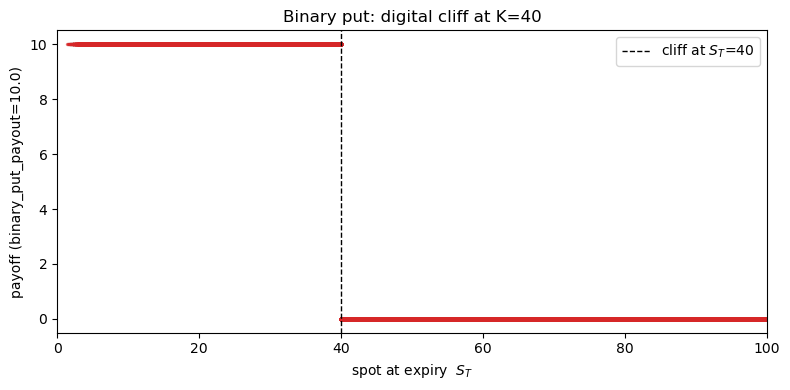

In [160]:
binary_put_spec    = MARKET['AC_40_BP']
binary_put_strike  = binary_put_spec['strike']
binary_put_payout  = binary_put_spec['binary_put_payout']

binary_put_payoff_per_unit = binary_put_payoff(spot_at_3w_expiry,
                                               binary_put_strike,
                                               amount=binary_put_payout)
prob_finishing_below_strike = (spot_at_3w_expiry < binary_put_strike).mean()
fair_value_per_unit = binary_put_payoff_per_unit.mean()
market_mid          = 0.5 * (binary_put_spec['bid'] + binary_put_spec['ask'])

print(f'P(S_T < {binary_put_strike})         = {prob_finishing_below_strike:.3f}')
print(f'Fair (binary_put_payout={binary_put_payout}) = {fair_value_per_unit:.3f}')
print(f"Market bid {binary_put_spec['bid']}/ask {binary_put_spec['ask']} mid {market_mid:.3f}"
      f'  ->  edge per unit = {fair_value_per_unit - market_mid:+.3f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(spot_at_3w_expiry, binary_put_payoff_per_unit, s=2, alpha=0.3, color='C3')
ax.axvline(binary_put_strike, color='k', ls='--', lw=1,
           label=f'cliff at $S_T$={binary_put_strike}')
ax.set(xlabel='spot at expiry  $S_T$',
       ylabel=f'payoff (binary_put_payout={binary_put_payout})',
       title=f'Binary put: digital cliff at K={binary_put_strike}',
       xlim=(0, 100))
ax.legend(); plt.tight_layout(); plt.show()

**Read this:** payoff is either 0 or `binary_put_payout` — no in-between. Each dot is on one of two horizontal lines.

### Replication: digital ≈ tight bull-put spread

A digital cliff cannot be built exactly from continuous put payoffs (puts are kinked, not jumps). But a *bull-put spread* — long one put at $K+\varepsilon$, short one at $K-\varepsilon$, both struck around the digital's strike $K$ — produces a **ramped digital** that converges to the cliff as $\varepsilon \to 0$.

**Construction.** With payout $A$:

$$\text{replication payoff}(S_T) \;=\; \frac{A}{2\varepsilon}\,\bigl[P(K+\varepsilon)\;-\;P(K-\varepsilon)\bigr]$$

Where $P(K')$ means a vanilla put with strike $K'$. Walk the three regions of $S_T$:

| Region | Long put $P(K+\varepsilon)$ | Short put $-P(K-\varepsilon)$ | Sum | Scaled by $A/2\varepsilon$ |
|---|---|---|---|---|
| $S_T \ge K+\varepsilon$ | $0$ | $0$ | $0$ | $0$ |
| $K-\varepsilon \le S_T < K+\varepsilon$ | $K+\varepsilon - S_T$ | $0$ | $K+\varepsilon - S_T$ | $\dfrac{A(K+\varepsilon - S_T)}{2\varepsilon}$ |
| $S_T < K-\varepsilon$ | $K+\varepsilon - S_T$ | $-(K-\varepsilon - S_T)$ | $2\varepsilon$ | $A$ |

Outside the band the replication matches the digital (0 above, $A$ below). Inside the band, the digital cliff is replaced by a **linear ramp** from $A$ at $S_T = K-\varepsilon$ down to $0$ at $S_T = K+\varepsilon$.

**Why it works (calculus view).** Recall $\partial P/\partial K = \mathbf{P}(S_T < K)$ under the risk-neutral measure (Breeden–Litzenberger). So a digital put fair value equals $A \cdot \partial P/\partial K \big|_{K}$. The bull-put spread is a *finite-difference* approximation of that derivative: $\frac{P(K+\varepsilon) - P(K-\varepsilon)}{2\varepsilon} \to \partial P/\partial K$ as $\varepsilon \to 0$. They agree at first order, and the residual is $O(\varepsilon^2)$.

**This contract.** $K = 40$, $A = 10$, available strikes $\{35, 40, 45\}$. Pick $\varepsilon = 5$ (largest possible — coarsest spread):

$$\text{replication} \;=\; \frac{10}{2 \cdot 5}\,\bigl[P(45) - P(35)\bigr] \;=\; P(45) - P(35)$$

So one synthetic digital = long one `AC_45_P` + short one `AC_35_P`. The ramp band is $[35, 45]$ — wide, so replication is quite imperfect. The next code cell prices it at touch and visualizes the residual.

--- fair values (per unit, MC) ---
  digital fair        = 5.225
  replication fair    = 5.210
  fair gap (digital - replication) = +0.015

--- prices at touch (per unit) ---
  binary put ask 5.100 / bid 5.000
  replication: buy at 4.770 / sell at 4.700

--- arb candidates ---
  (A) buy repl @ 4.770, sell digital @ 5.000  ->  credit +0.230,  E[terminal] -0.015,  total E[PnL] +0.215 per unit
  (B) sell repl @ 4.700, buy digital @ 5.100  ->  credit -0.400,  E[terminal] +0.015,  total E[PnL] -0.385 per unit
Worst case S_T just below 40: residual = −4.77 per unit (loss ~$715k worst-case across full size). Best case S_T just below 45: residual = +5.23 per unit. Outside [35,45]: locked-in +0.23.


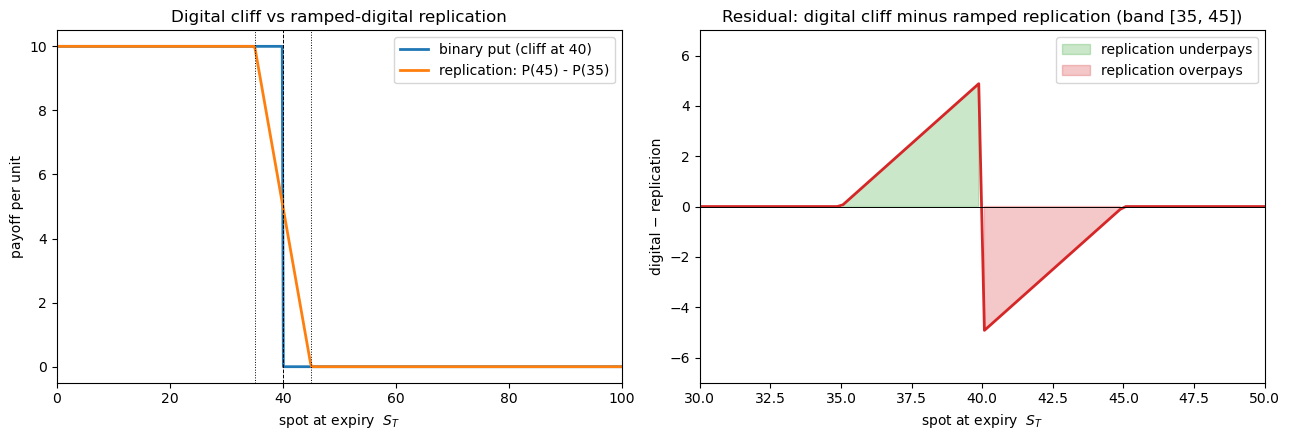

In [161]:
# --- Build the bull-put-spread replication for the binary put ---
put_low_spec  = MARKET['AC_35_P']    # short leg (K - epsilon)
put_high_spec = MARKET['AC_45_P']    # long  leg (K + epsilon)
strike_low    = put_low_spec['strike']
strike_high   = put_high_spec['strike']
epsilon       = (strike_high - strike_low) / 2.0          # = 5
spread_scale  = binary_put_payout / (2.0 * epsilon)       # = 10/10 = 1

# Replication payoff per path = scale * [P(K+eps) - P(K-eps)]
put_low_payoff_per_unit  = put_payoff(spot_at_3w_expiry, strike_low)
put_high_payoff_per_unit = put_payoff(spot_at_3w_expiry, strike_high)
replication_payoff_per_unit = spread_scale * (put_high_payoff_per_unit - put_low_payoff_per_unit)
replication_fair_value      = replication_payoff_per_unit.mean()

# At-touch prices: long replication = buy P(45) at ask, sell P(35) at bid
cost_to_buy_replication      = spread_scale * (put_high_spec['ask'] - put_low_spec['bid'])
proceeds_to_sell_replication = spread_scale * (put_high_spec['bid'] - put_low_spec['ask'])

print('--- fair values (per unit, MC) ---')
print(f'  digital fair        = {fair_value_per_unit:.3f}')
print(f'  replication fair    = {replication_fair_value:.3f}')
print(f'  fair gap (digital - replication) = {fair_value_per_unit - replication_fair_value:+.3f}')
print('\n--- prices at touch (per unit) ---')
print(f"  binary put ask {binary_put_spec['ask']:.3f} / bid {binary_put_spec['bid']:.3f}")
print(f'  replication: buy at {cost_to_buy_replication:.3f} / sell at {proceeds_to_sell_replication:.3f}')

# --- Two static-arb candidates against the live book ---
# (A) BUY replication, SELL binary
#     initial cash flow  = bid_binary - cost_to_buy_replication           (credit if positive)
#     terminal cash flow = replication_payoff - binary_payoff             (long repl, short binary)
# (B) SELL replication, BUY binary  (mirror image)
credit_A            = binary_put_spec['bid'] - cost_to_buy_replication
expected_terminal_A = (replication_payoff_per_unit - binary_put_payoff_per_unit).mean()
credit_B            = proceeds_to_sell_replication - binary_put_spec['ask']
expected_terminal_B = (binary_put_payoff_per_unit - replication_payoff_per_unit).mean()

print('\n--- arb candidates ---')
print(f'  (A) buy repl @ {cost_to_buy_replication:.3f}, sell digital @ {binary_put_spec["bid"]:.3f}'
      f'  ->  credit {credit_A:+.3f},  E[terminal] {expected_terminal_A:+.3f},'
      f'  total E[PnL] {credit_A + expected_terminal_A:+.3f} per unit')
print(f'  (B) sell repl @ {proceeds_to_sell_replication:.3f}, buy digital @ {binary_put_spec["ask"]:.3f}'
      f'  ->  credit {credit_B:+.3f},  E[terminal] {expected_terminal_B:+.3f},'
      f'  total E[PnL] {credit_B + expected_terminal_B:+.3f} per unit')


print("Worst case S_T just below 40: residual = −4.77 per unit (loss ~$715k worst-case across full size). Best case S_T just below 45: residual = +5.23 per unit. Outside [35,45]: locked-in +0.23.")
# --- Visualize: digital vs replication payoff vs S_T, plus residual ---
xs = np.linspace(0, 100, 500)
digital_curve     = binary_put_payout * (xs < binary_put_strike).astype(float)
replication_curve = spread_scale * (put_payoff(xs, strike_high) - put_payoff(xs, strike_low))
residual_curve    = digital_curve - replication_curve

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.plot(xs, digital_curve, lw=2, label=f'binary put (cliff at {binary_put_strike})')
ax.plot(xs, replication_curve, lw=2, label=f'replication: P({strike_high}) - P({strike_low})')
ax.axvline(strike_low, color='k', ls=':', lw=0.7)
ax.axvline(binary_put_strike, color='k', ls='--', lw=0.7)
ax.axvline(strike_high, color='k', ls=':', lw=0.7)
ax.set(xlabel='spot at expiry  $S_T$', ylabel='payoff per unit',
       title='Digital cliff vs ramped-digital replication', xlim=(0, 100))
ax.legend()

ax = axes[1]
ax.plot(xs, residual_curve, color='C3', lw=2)
ax.axhline(0, color='k', lw=0.7)
ax.fill_between(xs, residual_curve, 0, where=(residual_curve > 0), alpha=0.25, color='C2',
                label='replication underpays')
ax.fill_between(xs, residual_curve, 0, where=(residual_curve < 0), alpha=0.25, color='C3',
                label='replication overpays')
ax.set(xlabel='spot at expiry  $S_T$', ylabel='digital − replication',
       title=f'Residual: digital cliff minus ramped replication (band [{strike_low}, {strike_high}])',
       xlim=(30, 50), ylim=(-7, 7))
ax.legend()
plt.tight_layout(); plt.show()



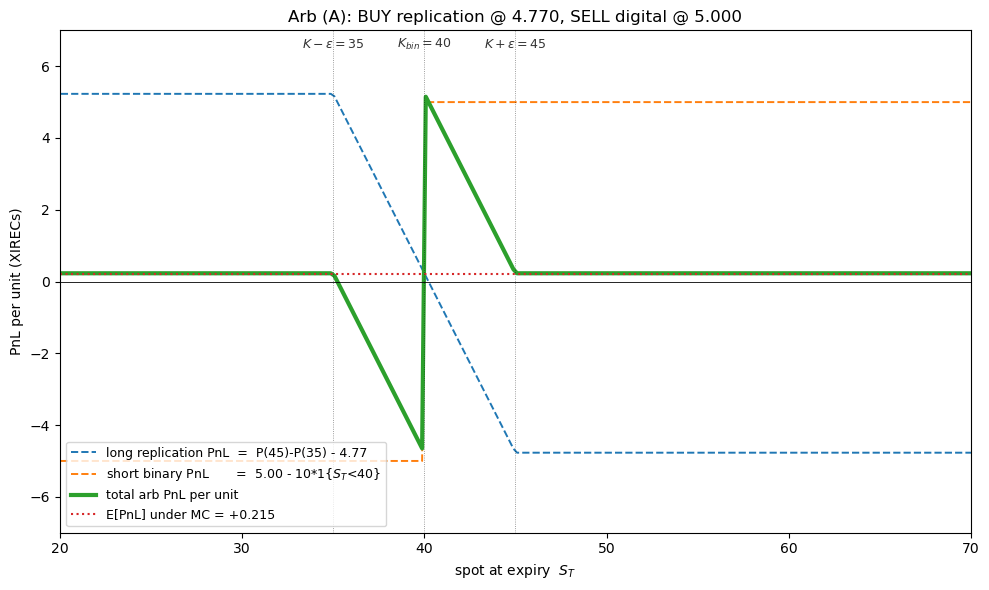

S_T < 35                : PnL = +0.230   (repl pays 10, binary pays 10; legs cancel; only credit remains)
35 <= S_T < 40        : PnL = +0.230 + (S_T - 35*1)  ... ramps from +0.230 at S_T=35 down to -4.770 at S_T=40 (worst)
40 <= S_T < 45        : PnL = +0.230 + (45 - S_T)   ... ramps from +5.230 at S_T=40 (best) down to +0.230 at S_T=45
S_T >= 45               : PnL = +0.230   (both payoffs zero; only credit)

E[PnL] (MC) = +0.215 per unit
Scaled to max size 50 contracts * 3000 multiplier: E[PnL] = +32,262 XIRECs


In [162]:
# --- PnL of arb (A): BUY replication, SELL digital, vs S_T ---
# Per unit, decomposed into the two legs:
#   long replication leg PnL  = replication_payoff - cost_to_buy_replication
#   short binary       leg PnL = bid_binary - binary_payoff
xs = np.linspace(0, 100, 500)
replication_curve_xs = spread_scale * (put_payoff(xs, strike_high) - put_payoff(xs, strike_low))
binary_curve_xs      = binary_put_payout * (xs < binary_put_strike).astype(float)

leg_long_repl_pnl    = replication_curve_xs - cost_to_buy_replication
leg_short_binary_pnl = binary_put_spec['bid'] - binary_curve_xs
total_arb_pnl_xs     = leg_long_repl_pnl + leg_short_binary_pnl

expected_pnl = credit_A + expected_terminal_A   # already computed above

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(xs, leg_long_repl_pnl,    lw=1.4, ls='--', color='C0',
        label=f'long replication PnL  =  P({strike_high})-P({strike_low}) - {cost_to_buy_replication:.2f}')
ax.plot(xs, leg_short_binary_pnl, lw=1.4, ls='--', color='C1',
        label=f'short binary PnL       =  {binary_put_spec["bid"]:.2f} - {binary_put_payout:.0f}*1{{$S_T$<{binary_put_strike}}}')
ax.plot(xs, total_arb_pnl_xs, lw=3, color='C2',
        label='total arb PnL per unit')
ax.axhline(0, color='k', lw=0.6)
ax.axhline(expected_pnl, color='C3', ls=':', lw=1.5,
           label=f'E[PnL] under MC = {expected_pnl:+.3f}')

# Vertical strike markers
for x, lbl in [(strike_low, f'$K-\\varepsilon={strike_low}$'),
               (binary_put_strike, f'$K_{{bin}}={binary_put_strike}$'),
               (strike_high, f'$K+\\varepsilon={strike_high}$')]:
    ax.axvline(x, color='k', ls=':', lw=0.6, alpha=0.5)
    ax.text(x, 6.5, lbl, ha='center', fontsize=9, alpha=0.8)

ax.set(xlabel='spot at expiry  $S_T$', ylabel='PnL per unit (XIRECs)',
       title=f"Arb (A): BUY replication @ {cost_to_buy_replication:.3f}, SELL digital @ {binary_put_spec['bid']:.3f}",
       xlim=(20, 70), ylim=(-7, 7))
ax.legend(loc='lower left', fontsize=9)
plt.tight_layout(); plt.show()

# Region-by-region readout
print(f'S_T < {strike_low}                : PnL = {credit_A:+.3f}   '
      f'(repl pays {binary_put_payout:.0f}, binary pays {binary_put_payout:.0f}; legs cancel; only credit remains)')
print(f'{strike_low} <= S_T < {binary_put_strike}        : PnL = {credit_A:+.3f} + (S_T - {strike_low}*1)  '
      f'... ramps from {credit_A:+.3f} at S_T={strike_low} down to {credit_A + (strike_high - binary_put_strike) - binary_put_payout:+.3f} at S_T={binary_put_strike} (worst)')
print(f'{binary_put_strike} <= S_T < {strike_high}        : PnL = {credit_A:+.3f} + ({strike_high} - S_T)   '
      f'... ramps from {credit_A + (strike_high - binary_put_strike):+.3f} at S_T={binary_put_strike} (best) down to {credit_A:+.3f} at S_T={strike_high}')
print(f'S_T >= {strike_high}               : PnL = {credit_A:+.3f}   (both payoffs zero; only credit)')
print(f'\nE[PnL] (MC) = {expected_pnl:+.3f} per unit')
print(f'Scaled to max size 50 contracts * 3000 multiplier: '
      f'E[PnL] = {50*3000*expected_pnl:+,.0f} XIRECs')

Per-unit PnL stats over 1,000,000 paths:
  mean       = +0.2151
  std        = +1.0715
  min        = -4.7700
  max        = +5.2299
  p05        = -1.3009
  p50        = +0.2300
  p95        = +1.4202
  win_rate   = +0.9301
  sharpe   = +0.2007   (mean / std)

--- variance decomposition by S_T region ---
region          P(region)    E[PnL|R]   E[PnL^2|R]   contrib_to_E[PnL^2]
  S_T<35          0.44901     +0.2300       0.0529              +0.02375
  35<=S_T<40      0.07347     -2.2174       7.0018              +0.51439
  40<=S_T<45      0.06463     +2.7812       9.8176              +0.63448
  S_T>=45         0.41290     +0.2300       0.0529              +0.02184

  E[PnL^2] (sum of contribs) = 1.19446
  E[PnL]^2                   = 0.04626
  Var(PnL) = E[PnL^2] - E[PnL]^2 = 1.14820   (check: std^2 = 1.14820)

  P(S_T in band [35,45]) = 0.13809   -- only this fraction of paths contributes any variance.

--- sizing math ---
Total PnL  = N_contracts * 3000 * PnL_per_unit
=> E[PnL] and st

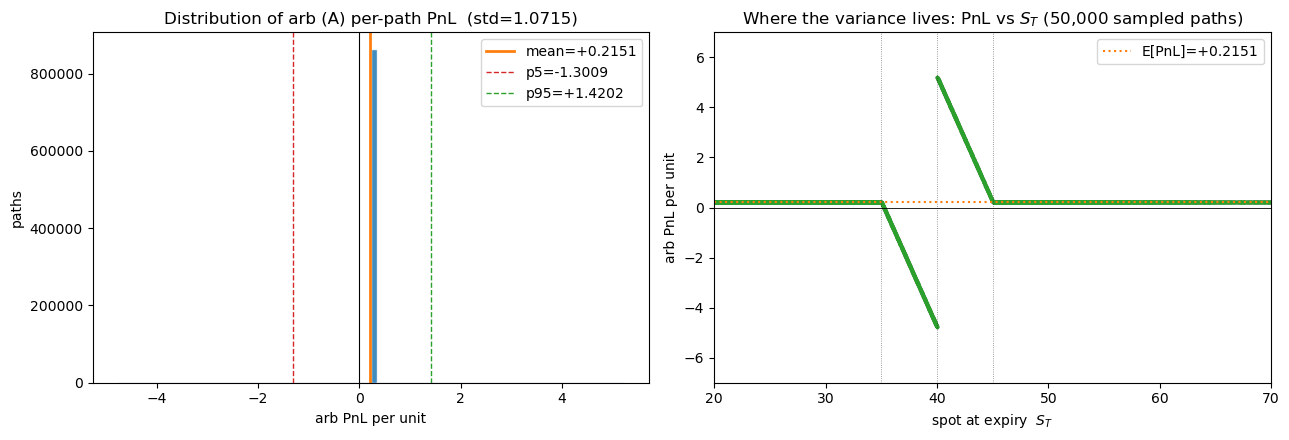


--- conclusion: WHY the spread reduces variance ---
Long binary alone -> PnL is ~Bernoulli with payoff in {0, 10}, less the 5.10 entry,
so PnL takes values in {-5.10, +4.90}.  Std (1M paths) = 4.9949.

Arb (A) cancels the digital cliff outside [35, 45]: both legs pay 0 above 45 or both
pay 10 below 35, so PnL is locked at +0.230.  P(S_T outside band) = 0.8619.
Inside the band the linear ramp doesn't match the cliff; residual is bounded in
[-5, +5].  P(S_T in band) = 0.1381 -- only that fraction has any noise.

Result (1M paths):  arb std = 1.0715  vs  long-binary std = 4.9949.
That IS the point of the spread: replace one big binary jump with a pair of put-leg
moves that cancel each other almost everywhere -- variance reduction by hedging.

Cannot reduce variance further from listed strikes -- proven by the no-exact-match
argument on {35, 40, 45}.  Tighter ramp would need P(38) or P(42).


In [163]:
# --- Variance of arb (A) per path, with region-by-region decomposition ---
# Per-path PnL of long replication + short binary, including initial credit.
arb_pnl_per_path = (replication_payoff_per_unit - cost_to_buy_replication) \
                 + (binary_put_spec['bid'] - binary_put_payoff_per_unit)

# Where each path lands relative to the strike grid {35, 40, 45}
sT = spot_at_3w_expiry
mask_far_below   = sT < strike_low                                # S_T < 35
mask_band_lower  = (sT >= strike_low)  & (sT < binary_put_strike) # [35, 40)
mask_band_upper  = (sT >= binary_put_strike) & (sT < strike_high) # [40, 45)
mask_far_above   = sT >= strike_high                              # S_T >= 45

stats = {
    'mean':  arb_pnl_per_path.mean(),
    'std':   arb_pnl_per_path.std(ddof=1),
    'min':   arb_pnl_per_path.min(),
    'max':   arb_pnl_per_path.max(),
    'p05':   np.percentile(arb_pnl_per_path, 5),
    'p50':   np.percentile(arb_pnl_per_path, 50),
    'p95':   np.percentile(arb_pnl_per_path, 95),
    'win_rate': (arb_pnl_per_path > 0).mean(),
}
print(f"Per-unit PnL stats over {len(arb_pnl_per_path):,} paths:")
for k, v in stats.items():
    print(f"  {k:10s} = {v:+.4f}" if isinstance(v, float) else f"  {k:10s} = {v}")
print(f"  sharpe   = {stats['mean']/stats['std']:+.4f}   (mean / std)")

# --- Region decomposition: where is the variance coming from? ---
# Var(PnL) = E[PnL^2] - (E[PnL])^2.
# Split E[PnL^2] by S_T region; outside [35,45] the residual is exactly 0,
# so PnL is locked at +0.230 there and contributes only to the mean^2 term.
print("\n--- variance decomposition by S_T region ---")
print(f"{'region':14s} {'P(region)':>10s}  {'E[PnL|R]':>10s}  {'E[PnL^2|R]':>11s}  {'contrib_to_E[PnL^2]':>20s}")
contrib_total = 0.0
for label, m in [('S_T<35',     mask_far_below),
                 ('35<=S_T<40', mask_band_lower),
                 ('40<=S_T<45', mask_band_upper),
                 ('S_T>=45',    mask_far_above)]:
    p_r        = m.mean()
    if p_r == 0: continue
    pnl_r      = arb_pnl_per_path[m]
    e_pnl      = pnl_r.mean()
    e_pnl_sq   = (pnl_r**2).mean()
    contrib    = p_r * e_pnl_sq
    contrib_total += contrib
    print(f"  {label:12s} {p_r:>10.5f}  {e_pnl:>+10.4f}  {e_pnl_sq:>11.4f}  {contrib:>+20.5f}")

var_check = contrib_total - stats['mean']**2
print(f"\n  E[PnL^2] (sum of contribs) = {contrib_total:.5f}")
print(f"  E[PnL]^2                   = {stats['mean']**2:.5f}")
print(f"  Var(PnL) = E[PnL^2] - E[PnL]^2 = {var_check:.5f}   "
      f"(check: std^2 = {stats['std']**2:.5f})")
prob_in_band = (mask_band_lower | mask_band_upper).mean()
print(f"\n  P(S_T in band [35,45]) = {prob_in_band:.5f}   "
      f"-- only this fraction of paths contributes any variance.")

# --- Sizing: how std and worst-case scale with contracts ---
print('\n--- sizing math ---')
print('Total PnL  = N_contracts * 3000 * PnL_per_unit')
print('=> E[PnL] and std[PnL] both scale LINEARLY in N_contracts.')
print('=> Sharpe = E/std is invariant to size; can only be improved by changing the trade.\n')
print(f"{'N_contracts':>12s}  {'E[PnL]':>10s}  {'std[PnL]':>10s}  {'5% worst':>12s}")
for N in (1, 10, 25, 50):
    scale = N * 3000
    print(f"{N:>12d}  {scale*stats['mean']:>+10,.0f}  {scale*stats['std']:>+10,.0f}  "
          f"{scale*stats['p05']:>+12,.0f}")

# --- Compare arb (A) vs simpler trades that share part of its edge ---
buy_binary_pnl  = binary_put_payoff_per_unit - binary_put_spec['ask']    # long binary at ask
long_p45_pnl    = put_high_payoff_per_unit  - put_high_spec['ask']       # long P(45) at ask alone
short_p35_pnl   = put_low_spec['bid']       - put_low_payoff_per_unit    # short P(35) at bid alone

print('\n--- comparison of single-leg trades (per unit) ---')
for name, x in [('arb (A): buy repl, sell binary', arb_pnl_per_path),
                ('long binary at ask',             buy_binary_pnl),
                ('long P(45) at ask',              long_p45_pnl),
                ('short P(35) at bid',             short_p35_pnl)]:
    m, s = x.mean(), x.std(ddof=1)
    print(f"  {name:32s} E={m:+.4f}  std={s:.4f}  sharpe={m/s:+.4f}")

# --- Histogram and S_T-conditional view ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.hist(arb_pnl_per_path, bins=80, color='C0', edgecolor='white', alpha=0.85)
ax.axvline(0, color='k', lw=0.8)
ax.axvline(stats['mean'], color='C1', lw=2, label=f"mean={stats['mean']:+.4f}")
ax.axvline(stats['p05'],  color='C3', ls='--', lw=1, label=f"p5={stats['p05']:+.4f}")
ax.axvline(stats['p95'],  color='C2', ls='--', lw=1, label=f"p95={stats['p95']:+.4f}")
ax.set(xlabel='arb PnL per unit', ylabel='paths',
       title=f'Distribution of arb (A) per-path PnL  (std={stats["std"]:.4f})')
ax.legend()

ax = axes[1]
# subsample for plotting; 1M points is too many for scatter
N_plot = min(50_000, len(arb_pnl_per_path))
idx_plot = np.random.default_rng(0).choice(len(arb_pnl_per_path), N_plot, replace=False)
ax.scatter(spot_at_3w_expiry[idx_plot], arb_pnl_per_path[idx_plot], s=2, alpha=0.25, color='C2')
ax.axhline(0, color='k', lw=0.6)
ax.axhline(stats['mean'], color='C1', ls=':', lw=1.5, label=f"E[PnL]={stats['mean']:+.4f}")
for x in (strike_low, binary_put_strike, strike_high):
    ax.axvline(x, color='k', ls=':', lw=0.6, alpha=0.5)
ax.set(xlabel='spot at expiry  $S_T$', ylabel='arb PnL per unit',
       title=f'Where the variance lives: PnL vs $S_T$ ({N_plot:,} sampled paths)',
       xlim=(20, 70), ylim=(-7, 7))
ax.legend()
plt.tight_layout(); plt.show()

# --- Conclusion using the actual 1M-path numbers ---
binary_std = buy_binary_pnl.std(ddof=1)
print("\n--- conclusion: WHY the spread reduces variance ---")
print(f"Long binary alone -> PnL is ~Bernoulli with payoff in {{0, 10}}, less the 5.10 entry,")
print(f"so PnL takes values in {{-5.10, +4.90}}.  Std (1M paths) = {binary_std:.4f}.")
print(f"")
print(f"Arb (A) cancels the digital cliff outside [35, 45]: both legs pay 0 above 45 or both")
print(f"pay 10 below 35, so PnL is locked at +0.230.  P(S_T outside band) = {1-prob_in_band:.4f}.")
print(f"Inside the band the linear ramp doesn't match the cliff; residual is bounded in")
print(f"[-5, +5].  P(S_T in band) = {prob_in_band:.4f} -- only that fraction has any noise.")
print(f"")
print(f"Result (1M paths):  arb std = {stats['std']:.4f}  vs  long-binary std = {binary_std:.4f}.")
print(f"That IS the point of the spread: replace one big binary jump with a pair of put-leg")
print(f"moves that cancel each other almost everywhere -- variance reduction by hedging.")
print(f"")
print(f"Cannot reduce variance further from listed strikes -- proven by the no-exact-match")
print(f"argument on {{35, 40, 45}}.  Tighter ramp would need P(38) or P(42).")

## 3. Knock-out put — *the* path dependency story

**Contract:** `AC_45_KO`. Strike $K=45$, barrier $B=35$, expiry 21d (confirmed from manual). Acts like a regular put with strike 45 — *unless* the path ever falls below 35 before expiry. Then payoff = 0 forever.

$$\text{payoff} = \mathbf{1}\{\min_{t \le T} S_t \ge B\} \cdot \max(K - S_T, 0)$$

The new axis of risk: **$\min_t S_t$** (the lowest spot reached during life). Two paths with the same $S_T$ pay differently depending on whether either ever dipped below the barrier.

**Why both numbers matter.** Because $B = 35 < K = 45$, the contract has a non-trivial *survival corridor*: paths that finish in $[35, 45)$ AND never dipped below 35. Survivors there pay positive intrinsic. With $\sigma = 251\%$ that corridor is narrow — many paths will breach the barrier — but it is not empty.

In [164]:
ko_put_spec    = MARKET['AC_45_KO']
ko_strike      = ko_put_spec['strike']
ko_barrier     = ko_put_spec['barrier']

ko_put_payoff_per_unit = knockout_put_payoff(paths, K=ko_strike, barrier=ko_barrier)
path_was_knocked_out   = (min_spot_over_path < ko_barrier)
ko_fair_value          = ko_put_payoff_per_unit.mean()
ko_market_mid          = 0.5 * (ko_put_spec['bid'] + ko_put_spec['ask'])

print(f'Strike K = {ko_strike}, Barrier B = {ko_barrier}')
print(f'Fraction of paths that knock out:                {path_was_knocked_out.mean():.3f}')
print(f'Fraction in-the-money at expiry (S_T<{ko_strike}):       '
      f'{(spot_at_3w_expiry < ko_strike).mean():.3f}')
print(f'Fraction in-the-money AND survived (still pays): '
      f'{((spot_at_3w_expiry < ko_strike) & ~path_was_knocked_out).mean():.3f}')
print(f'MC fair value:                                   {ko_fair_value:.6f}')
print(f"Market: bid {ko_put_spec['bid']}/ask {ko_put_spec['ask']} mid {ko_market_mid:.4f}  "
      f'-> edge per unit (vs sell at bid) = {ko_put_spec["bid"] - ko_fair_value:+.4f}')

Strike K = 45, Barrier B = 35
Fraction of paths that knock out:                0.693
Fraction in-the-money at expiry (S_T<45):       0.587
Fraction in-the-money AND survived (still pays): 0.032
MC fair value:                                   0.131121
Market: bid 0.15/ask 0.175 mid 0.1625  -> edge per unit (vs sell at bid) = +0.0189


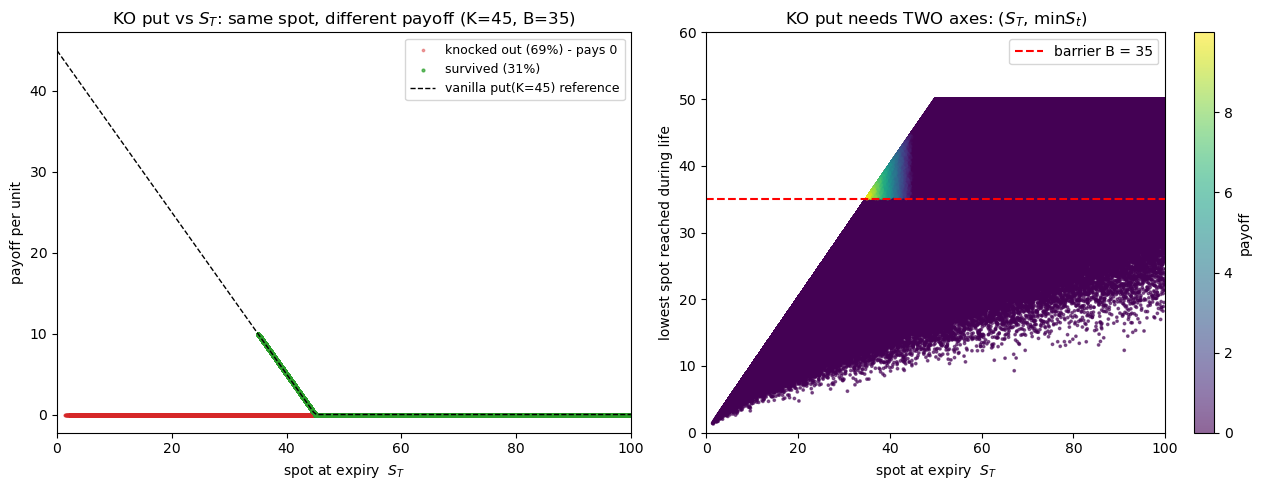

In [165]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: payoff vs S_T, colored by barrier-touch outcome
ax = axes[0]
ax.scatter(spot_at_3w_expiry[ path_was_knocked_out],
           ko_put_payoff_per_unit[ path_was_knocked_out],
           s=3, alpha=0.4, color='C3',
           label=f'knocked out ({path_was_knocked_out.mean():.0%}) - pays 0')
ax.scatter(spot_at_3w_expiry[~path_was_knocked_out],
           ko_put_payoff_per_unit[~path_was_knocked_out],
           s=4, alpha=0.7, color='C2',
           label=f'survived ({(~path_was_knocked_out).mean():.0%})')
vanilla_curve_xs = np.linspace(0, 100, 200)
ax.plot(vanilla_curve_xs, put_payoff(vanilla_curve_xs, ko_strike),
        'k--', lw=1, label=f'vanilla put(K={ko_strike}) reference')
ax.set(xlabel='spot at expiry  $S_T$', ylabel='payoff per unit',
       title=f'KO put vs $S_T$: same spot, different payoff (K={ko_strike}, B={ko_barrier})',
       xlim=(0, 100))
ax.legend(fontsize=9)

# Right: 2D state — the *real* picture
ax = axes[1]
scatter = ax.scatter(spot_at_3w_expiry, min_spot_over_path,
                     c=ko_put_payoff_per_unit, s=3, alpha=0.6, cmap='viridis')
ax.axhline(ko_barrier, color='r', ls='--', lw=1.5, label=f'barrier B = {ko_barrier}')
ax.set(xlabel='spot at expiry  $S_T$',
       ylabel='lowest spot reached during life',
       title='KO put needs TWO axes: ($S_T$, $\\min S_t$)',
       xlim=(0, 100), ylim=(0, max(60, min_spot_over_path.max())))
plt.colorbar(scatter, ax=ax, label='payoff')
ax.legend(); plt.tight_layout(); plt.show()

**Read these:**

*Left plot:* at each `S_T < 45`, paths split into red (knocked, pays 0) and green (survived, pays vanilla intrinsic). Green points only appear roughly in `S_T ∈ [35, 45)` — to be ITM `S_T < 45`, and to have survived `min S_t ≥ 35`, which forces `S_T ≥ 35`. That narrow corridor is what gives the contract any value at all.

*Right plot:* the true state space is 2D — `(S_T, min S_t)`. Above the red barrier line `B = 35`, payoff lives. Below, it dies. A vanilla put would produce horizontal stripes (constant in the y-axis); the KO put has a sharp boundary at the barrier.

**Trade implication.** With $\sigma = 251\%$ paths are wild; ~70% breach the 35 barrier. Fair value is small (~0.13 per unit) but **not zero** — there is a real survival corridor, and ~3% of paths pay positive intrinsic. Compare to market mid 0.1625:
- **Sell at bid 0.15** — only marginally above fair (~+0.02 edge per unit). 500-cap × 3000 multiplier ≈ +30k expected, but with real tail risk: the surviving-and-ITM paths can pay close to 10 per unit, so worst-case loss per unit is large.
- **Buy at ask 0.175** — *above* fair, negative edge. Don't.

=== marginal P(knock state) ===
  P(knocked)         = 0.69287
  P(survived)        = 0.30713

=== S_T | knocked ===
  E[S_T|knocked]     =  33.418   median = 28.859   P5/P95 = 10.315/72.748
  P(S_T < 45 | knocked)   = 0.8017   (no payoff anyway -- knocked is dead)
  P(S_T < 35 | knocked)   = 0.6480   (deep losers; min already <35, so finishing low is common)

=== S_T | survived ===
  E[S_T|survived]     =  87.033   median = 72.866   P5/P95 = 41.030/180.621
  P(S_T < 45 | survived)  = 0.1030   (this is the ONLY bucket that pays the KO put)
  P(S_T >= 45 | survived) = 0.8970   (survivors finishing OTM)
  E[max(45-S_T,0) | survived] = 0.4269
  -> KO fair = P(survived) * E[max(45-S_T,0) | survived]
             = 0.3071 * 0.4269 = 0.1311   (matches direct MC fair 0.1311)


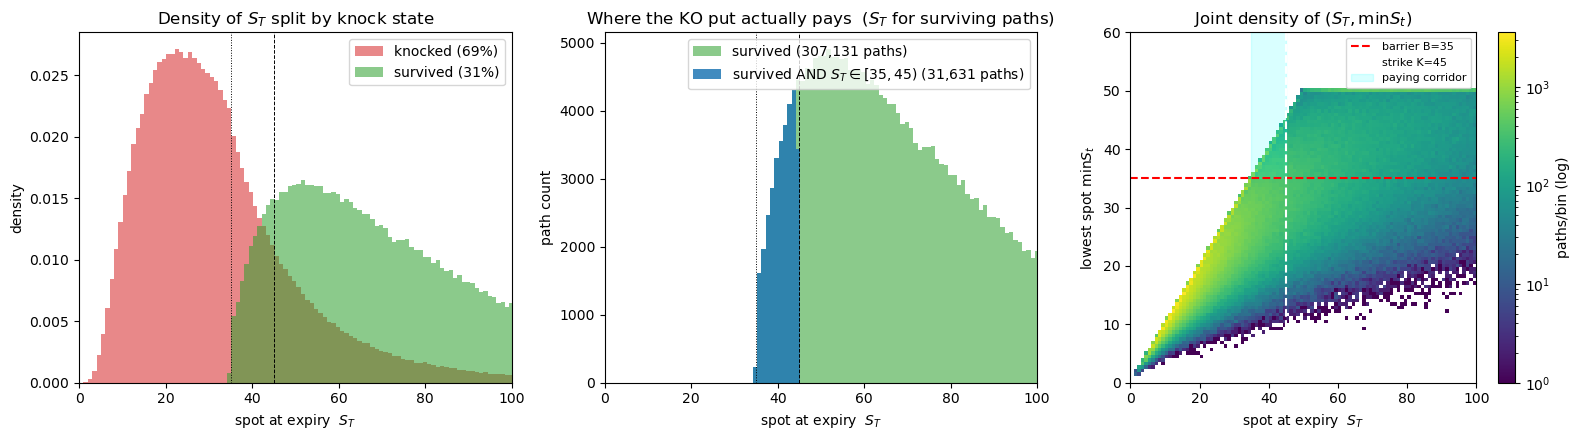

In [166]:
# --- (c) Conditional distributions of S_T given KO state ---
# Goal: see where the mass actually lives, in particular where the surviving-AND-ITM
# corridor sits inside the full S_T distribution.

knocked     = path_was_knocked_out
survived    = ~knocked
sT_knocked  = spot_at_3w_expiry[knocked]
sT_survived = spot_at_3w_expiry[survived]

# Marginal stats
print('=== marginal P(knock state) ===')
print(f'  P(knocked)         = {knocked.mean():.5f}')
print(f'  P(survived)        = {survived.mean():.5f}')

# Conditional moments
def stats(name, x):
    return (f'  E[{name}]     = {x.mean():>7.3f}'
            f'   median = {np.median(x):>6.3f}'
            f'   P5/P95 = {np.percentile(x,5):>6.3f}/{np.percentile(x,95):>6.3f}')

print('\n=== S_T | knocked ===')
print(stats('S_T|knocked', sT_knocked))
print(f'  P(S_T < 45 | knocked)   = {(sT_knocked < 45).mean():.4f}   '
      f'(no payoff anyway -- knocked is dead)')
print(f'  P(S_T < 35 | knocked)   = {(sT_knocked < 35).mean():.4f}   '
      f'(deep losers; min already <35, so finishing low is common)')

print('\n=== S_T | survived ===')
print(stats('S_T|survived', sT_survived))
print(f'  P(S_T < 45 | survived)  = {(sT_survived < 45).mean():.4f}   '
      f'(this is the ONLY bucket that pays the KO put)')
print(f'  P(S_T >= 45 | survived) = {(sT_survived >= 45).mean():.4f}   '
      f'(survivors finishing OTM)')
print(f'  E[max(45-S_T,0) | survived] = {np.maximum(45-sT_survived,0).mean():.4f}')
print(f'  -> KO fair = P(survived) * E[max(45-S_T,0) | survived]')
print(f'             = {survived.mean():.4f} * {np.maximum(45-sT_survived,0).mean():.4f}'
      f' = {survived.mean() * np.maximum(45-sT_survived,0).mean():.4f}'
      f'   (matches direct MC fair {ko_fair_value:.4f})')

# --- Side-by-side density of S_T conditional on state ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

bins = np.linspace(0, 200, 200)
ax = axes[0]
ax.hist(sT_knocked,  bins=bins, density=True, alpha=0.55, color='C3',
        label=f'knocked ({knocked.mean():.0%})')
ax.hist(sT_survived, bins=bins, density=True, alpha=0.55, color='C2',
        label=f'survived ({survived.mean():.0%})')
ax.axvline(35, color='k', ls=':',  lw=0.7)
ax.axvline(45, color='k', ls='--', lw=0.7)
ax.set(xlabel='spot at expiry  $S_T$', ylabel='density',
       title='Density of $S_T$ split by knock state', xlim=(0, 100))
ax.legend()

# Zoomed: where the corridor lives
ax = axes[1]
mask_corridor = survived & (spot_at_3w_expiry >= 35) & (spot_at_3w_expiry < 45)
sT_corridor = spot_at_3w_expiry[mask_corridor]
ax.hist(sT_survived, bins=bins, density=False, alpha=0.55, color='C2',
        label=f'survived ({survived.sum():,} paths)')
ax.hist(sT_corridor, bins=bins, density=False, alpha=0.85, color='C0',
        label=f'survived AND $S_T\\in[35,45)$ ({mask_corridor.sum():,} paths)')
ax.axvline(35, color='k', ls=':', lw=0.7);  ax.axvline(45, color='k', ls='--', lw=0.7)
ax.set(xlabel='spot at expiry  $S_T$', ylabel='path count',
       title='Where the KO put actually pays  ($S_T$ for surviving paths)',
       xlim=(0, 100))
ax.legend()

# 2D heatmap of (S_T, min S_t) — the real state space
from matplotlib.colors import LogNorm
ax = axes[2]
hist2d, xedges, yedges, _ = ax.hist2d(spot_at_3w_expiry, min_spot_over_path,
                                       bins=[100, 100], range=[[0, 100], [0, 60]],
                                       cmin=1, norm=LogNorm())
ax.axhline(35, color='red', ls='--', lw=1.5, label='barrier B=35')
ax.axvline(45, color='white', ls='--', lw=1.5, label='strike K=45')
# Mark the corridor visually
ax.fill_betweenx([35, 60], 35, 45, color='cyan', alpha=0.15, label='paying corridor')
ax.set(xlabel='spot at expiry  $S_T$', ylabel='lowest spot $\\min S_t$',
       title='Joint density of $(S_T, \\min S_t)$', xlim=(0,100), ylim=(0,60))
ax.legend(fontsize=8, loc='upper right')
plt.colorbar(_, ax=ax, label='paths/bin (log)')
plt.tight_layout(); plt.show()

cov(P(45), KO)   = -0.6801
var(KO)          = 0.7560
var(P(45))       = 147.7021
corr(P(45), KO)  = -0.0644
k_var_min        = cov / var(KO) = -0.8995

       k     E[PnL]        std   sharpe    note
  0.0000    +1.9839    12.1533  +0.1632    long P(45) only (raw)
  0.5000    +1.9933    12.1890  +0.1635    
  1.0000    +2.0028    12.2400  +0.1636    1:1  ==  long DIP synthetic
 -0.8995    +1.9669    12.1281  +0.1622    <-- VAR-MIN
  2.0000    +2.0216    12.3874  +0.1632    
  5.0000    +2.0783    13.1683  +0.1578    
 10.0000    +2.1727    15.3918  +0.1412    

Sharpe-max hedge ratio: k = 0.9679  -> E=+2.0021  std=12.2363  sharpe=+0.1636


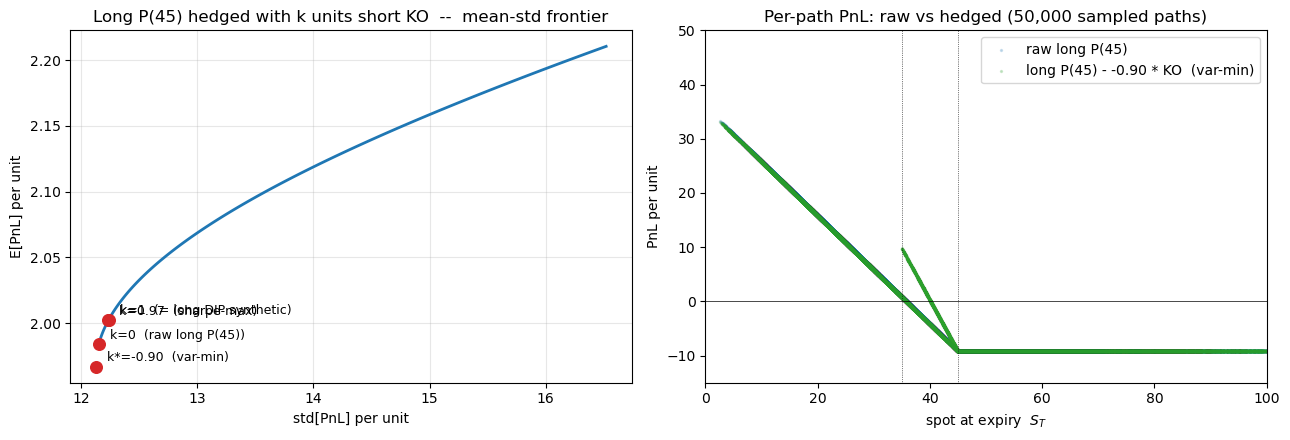


=== sizing at platform caps (50 P(45), up to 500 KO) ===
  N_KO   k=N_KO/N_P45          E[PnL]        std[PnL]    sharpe        5% worst
     0           0.00        +297,581       1,822,991   +0.1632      -1,365,000
    25           0.50        +298,997       1,828,347   +0.1635      -1,353,750
    50           1.00        +300,413       1,836,004   +0.1636      -1,342,500
   100           2.00        +303,244       1,858,104   +0.1632      -1,320,000
   200           4.00        +308,908       1,928,183   +0.1602      -1,275,000
   350           7.00        +317,404       2,090,708   +0.1518      -1,207,500
   500          10.00        +325,900       2,308,772   +0.1412      -1,140,000


In [167]:
# --- (e) KO as a hedge for long P(45) ---
# Identity:    P(45) = DOP(45, 35) + DIP(45, 35) = KO_put + DIP
# So  P(45) - KO = DIP (down-and-IN put): pays max(45-S_T, 0) iff knocked.
#
# Question: hedging long P(45) by shorting KO subtracts the tiny "survived AND ITM"
# slice from the payoff.  We trade away ~3% of the probability mass and ~0.13 in fair
# value.  Does the resulting std drop enough to be worth it?

P45_payoff = put_high_payoff_per_unit                            # = put_payoff(sT, 45)
KO_payoff  = ko_put_payoff_per_unit                              # K=45, B=35

P45_ask = MARKET['AC_45_P']['ask']
P45_bid = MARKET['AC_45_P']['bid']
KO_bid  = MARKET['AC_45_KO']['bid']
KO_ask  = MARKET['AC_45_KO']['ask']

# Baseline: long 1 P(45) at ask.  Short k units of KO at bid (per unit of long P45).
X_long_P45 = P45_payoff - P45_ask
def hedged_pnl(k):
    return X_long_P45 + k * (KO_bid - KO_payoff)

# Variance-min hedge ratio:  d/dk Var(P45 - k KO) = -2 Cov + 2k Var(KO) = 0
cov_p45_ko = np.cov(P45_payoff, KO_payoff, ddof=1)[0, 1]
var_ko     = KO_payoff.var(ddof=1)
var_p45    = P45_payoff.var(ddof=1)
corr       = cov_p45_ko / np.sqrt(var_ko * var_p45)
k_var_min  = cov_p45_ko / var_ko
print(f'cov(P(45), KO)   = {cov_p45_ko:.4f}')
print(f'var(KO)          = {var_ko:.4f}')
print(f'var(P(45))       = {var_p45:.4f}')
print(f'corr(P(45), KO)  = {corr:.4f}')
print(f'k_var_min        = cov / var(KO) = {k_var_min:.4f}\n')

# Sweep table
print(f'{"k":>8s} {"E[PnL]":>10s} {"std":>10s} {"sharpe":>8s}    note')
for k in [0.0, 0.5, 1.0, k_var_min, 2.0, 5.0, 10.0]:
    p = hedged_pnl(k)
    E, s = p.mean(), p.std(ddof=1)
    sh = E/s if s > 0 else 0.0
    note = ''
    if k == 0:                      note = 'long P(45) only (raw)'
    elif abs(k - 1.0) < 1e-6:       note = '1:1  ==  long DIP synthetic'
    elif abs(k - k_var_min) < 1e-3: note = '<-- VAR-MIN'
    print(f'{k:>8.4f} {E:>+10.4f} {s:>10.4f} {sh:>+8.4f}    {note}')

# Sharpe-max via line search (need to handle that hedge changes both E and Var)
mu_short_KO_per_unit = KO_bid - KO_payoff.mean()    # = +0.0189 (small positive)
def neg_sharpe(k):
    E = X_long_P45.mean() + k * mu_short_KO_per_unit
    V = var_p45 - 2*k*cov_p45_ko + k**2 * var_ko
    return -E/np.sqrt(max(V, 1e-12))
from scipy.optimize import minimize_scalar
res = minimize_scalar(neg_sharpe, bounds=(0, 30), method='bounded')
k_sh = res.x
p = hedged_pnl(k_sh)
print(f'\nSharpe-max hedge ratio: k = {k_sh:.4f}'
      f'  -> E={p.mean():+.4f}  std={p.std(ddof=1):.4f}  sharpe={p.mean()/p.std(ddof=1):+.4f}')

# --- visualize: frontier (E vs std) as we sweep k ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ks = np.linspace(0, 12, 120)
Es = np.array([hedged_pnl(k).mean() for k in ks])
ss = np.array([hedged_pnl(k).std(ddof=1) for k in ks])
ax.plot(ss, Es, lw=2, color='C0')
for k_mark, lbl in [(0,         'k=0  (raw long P(45))'),
                    (1,         'k=1  (= long DIP synthetic)'),
                    (k_var_min, f'k*={k_var_min:.2f}  (var-min)'),
                    (k_sh,      f'k={k_sh:.2f}  (sharpe-max)')]:
    p = hedged_pnl(k_mark)
    ax.scatter(p.std(ddof=1), p.mean(), s=70, zorder=5, color='C3')
    ax.annotate(lbl, (p.std(ddof=1), p.mean()), textcoords='offset points',
                xytext=(8, 4), fontsize=9)
ax.set(xlabel='std[PnL] per unit', ylabel='E[PnL] per unit',
       title='Long P(45) hedged with k units short KO  --  mean-std frontier')
ax.grid(alpha=0.3)

# --- per-path PnL scatter: raw vs at k* ---
ax = axes[1]
N_plot = 50_000
idx = np.random.default_rng(1).choice(len(P45_payoff), N_plot, replace=False)
ax.scatter(spot_at_3w_expiry[idx], X_long_P45[idx], s=2, alpha=0.20, color='C0',
           label='raw long P(45)')
hedged_at_kstar = hedged_pnl(k_var_min)[idx]
ax.scatter(spot_at_3w_expiry[idx], hedged_at_kstar, s=2, alpha=0.20, color='C2',
           label=f'long P(45) - {k_var_min:.2f} * KO  (var-min)')
ax.axhline(0, color='k', lw=0.5)
ax.axvline(35, color='k', ls=':', lw=0.5)
ax.axvline(45, color='k', ls=':', lw=0.5)
ax.set(xlabel='spot at expiry  $S_T$', ylabel='PnL per unit',
       title=f'Per-path PnL: raw vs hedged ({N_plot:,} sampled paths)',
       xlim=(0, 100), ylim=(-15, 50))
ax.legend()
plt.tight_layout(); plt.show()

# --- sizing at the platform caps ---
print('\n=== sizing at platform caps (50 P(45), up to 500 KO) ===')
N_P45 = 50
print(f'{"N_KO":>6s} {"k=N_KO/N_P45":>14s}  '
      f'{"E[PnL]":>14s}  {"std[PnL]":>14s}  {"sharpe":>8s}  {"5% worst":>14s}')
for N_KO in [0, 25, 50, 100, 200, 350, 500]:
    k = N_KO / N_P45
    p = hedged_pnl(k)
    E   = 3000 * N_P45 * p.mean()
    std = 3000 * N_P45 * p.std(ddof=1)
    p5  = 3000 * N_P45 * np.percentile(p, 5)
    sh  = E/std if std > 0 else 0
    print(f'{N_KO:>6d} {k:>14.2f}  {E:>+14,.0f}  {std:>14,.0f}  {sh:>+8.4f}  {p5:>+14,.0f}')

## 4. Chooser — a two-act story

**Contract:** `AC_50_CO`. Strike $K$, decision at the chooser-decision tick (day 14), expiry at the 3-week tick (day 21). At the decision tick the holder picks: should this become a call or a put? After that, it just behaves like the chosen vanilla.

**Optimal pick at $t_1$**: pick whichever has higher BS value remaining. Under $r=0$, this simplifies to: pick CALL if $S_{t_1} > K$, else PUT.

$$\text{payoff} = \begin{cases} \max(S_T - K, 0) & \text{if } S_{t_1} > K \\ \max(K - S_T, 0) & \text{if } S_{t_1} \le K \end{cases}$$

The new axis of risk: **decision-time spot $S_{t_1}$**. Two paths with the same $S_T$ but different $S_{t_1}$ pay differently.

In [168]:
chooser_spec      = MARKET['AC_50_CO']
chooser_strike    = chooser_spec['strike']
decision_tick     = chooser_spec['decision_tick']
expiry_tick       = chooser_spec['expiry_tick']

chooser_payoff_per_unit = chooser_payoff(paths, chooser_strike,
                                         t1_step=decision_tick, T_step=expiry_tick)

years_remaining_at_decision = (expiry_tick - decision_tick) * YEAR_FRACTION_PER_TICK
call_value_at_decision = bs_call(spot_at_chooser_decision, chooser_strike,
                                 years_remaining_at_decision)
put_value_at_decision  = bs_put (spot_at_chooser_decision, chooser_strike,
                                 years_remaining_at_decision)
holder_picked_call = call_value_at_decision >= put_value_at_decision

chooser_fair_value = mc_price(chooser_payoff_per_unit)[0]
chooser_market_mid = 0.5 * (chooser_spec['bid'] + chooser_spec['ask'])

print(f'Holder picks CALL at t1 on {holder_picked_call.mean():.0%} of paths')
print(f'Holder picks PUT  at t1 on {(~holder_picked_call).mean():.0%} of paths')
print(f'(Asymmetry: lognormal drift -sigma^2/2 pulls log S downward.)\n')
print(f'MC fair chooser price: {chooser_fair_value:.3f}')
print(f'Market mid           : {chooser_market_mid:.3f}'
      f'  -> edge per unit = {chooser_fair_value - chooser_market_mid:+.3f}')

Holder picks CALL at t1 on 38% of paths
Holder picks PUT  at t1 on 62% of paths
(Asymmetry: lognormal drift -sigma^2/2 pulls log S downward.)

MC fair chooser price: 25.688
Market mid           : 22.250  -> edge per unit = +3.438


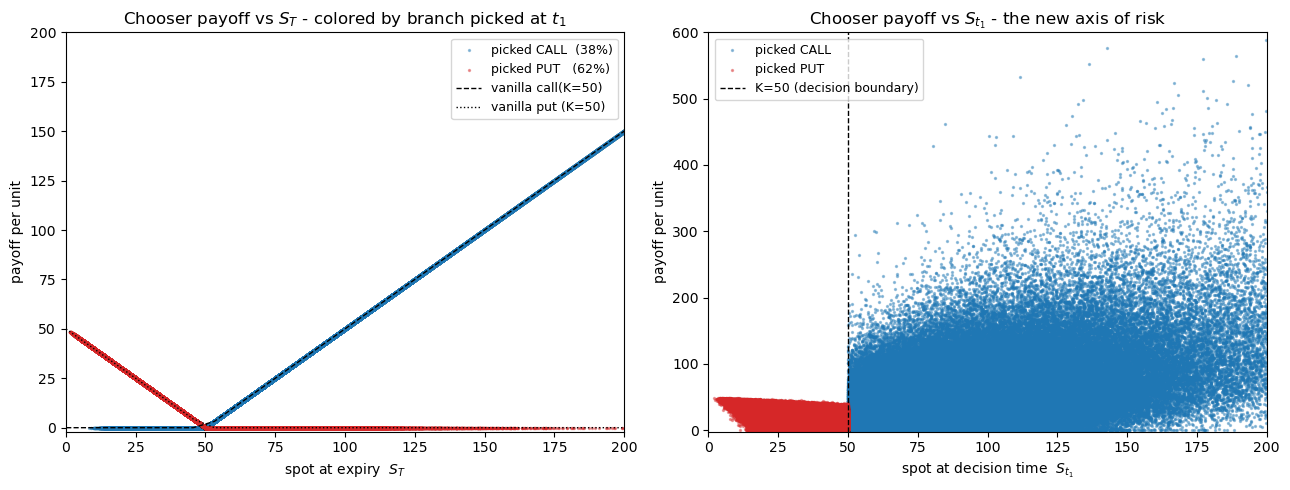

In [169]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: payoff vs S_T, colored by which branch was picked
ax = axes[0]
ax.scatter(spot_at_3w_expiry[ holder_picked_call],
           chooser_payoff_per_unit[ holder_picked_call],
           s=2, alpha=0.4, color='C0',
           label=f'picked CALL  ({holder_picked_call.mean():.0%})')
ax.scatter(spot_at_3w_expiry[~holder_picked_call],
           chooser_payoff_per_unit[~holder_picked_call],
           s=2, alpha=0.4, color='C3',
           label=f'picked PUT   ({(~holder_picked_call).mean():.0%})')
vanilla_xs = np.linspace(0.1, spot_at_3w_expiry.max(), 200)
ax.plot(vanilla_xs, np.maximum(vanilla_xs - chooser_strike, 0),
        'k--', lw=1, label=f'vanilla call(K={chooser_strike})')
ax.plot(vanilla_xs, np.maximum(chooser_strike - vanilla_xs, 0),
        'k:',  lw=1, label=f'vanilla put (K={chooser_strike})')
ax.set(xlabel='spot at expiry  $S_T$', ylabel='payoff per unit',
       title='Chooser payoff vs $S_T$ - colored by branch picked at $t_1$',
       xlim=(0, 200),ylim=(-2,200))
ax.legend(fontsize=9)

# Plot 2: payoff vs decision-time spot (the new axis)
ax = axes[1]
ax.scatter(spot_at_chooser_decision[ holder_picked_call],
           chooser_payoff_per_unit[ holder_picked_call],
           s=2, alpha=0.4, color='C0', label='picked CALL')
ax.scatter(spot_at_chooser_decision[~holder_picked_call],
           chooser_payoff_per_unit[~holder_picked_call],
           s=2, alpha=0.4, color='C3', label='picked PUT')
ax.axvline(chooser_strike, color='k', ls='--', lw=1,
           label=f'K={chooser_strike} (decision boundary)')
ax.set(xlabel='spot at decision time  $S_{t_1}$',
       ylabel='payoff per unit',
       title='Chooser payoff vs $S_{t_1}$ - the new axis of risk',
       xlim=(0, 200),ylim=(-2,600))
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

--- replication fairs and credits ---
  E[rep_orig]=25.6818  E[rep_alt]=25.7395  E[chooser]=25.6884
  cost(rep_orig)=21.800  cost(rep_alt)=21.800  chooser_bid=22.200
  upfront credit = +0.400 per unit

  E[res^2|orig]=127.4806  E[res^2|alt]=548.1318  => lambda*=0.8113

strategy                                     E[PnL]        std   sharpe
  Rep_orig: Call(T)+Put(t1)                  +0.3934    11.2907  +0.0348
  Rep_alt:  Put(T)+Call(t1)                  +0.4511    23.4122  +0.0193
  50/50 combo                                +0.4222    12.9963  +0.0325
  var-min combo (lambda*=0.811)          +0.4043    10.1699  +0.0398

--- per chooser short, vanilla legs needed ---
strategy                                      C_T      P_T     C_t1     P_t1      max_co
  Rep_orig: Call(T)+Put(t1)                 50.00     0.00     0.00    50.00       50.00
  Rep_alt:  Put(T)+Call(t1)                  0.00    50.00    50.00     0.00       50.00
  50/50 combo                               25.00    25

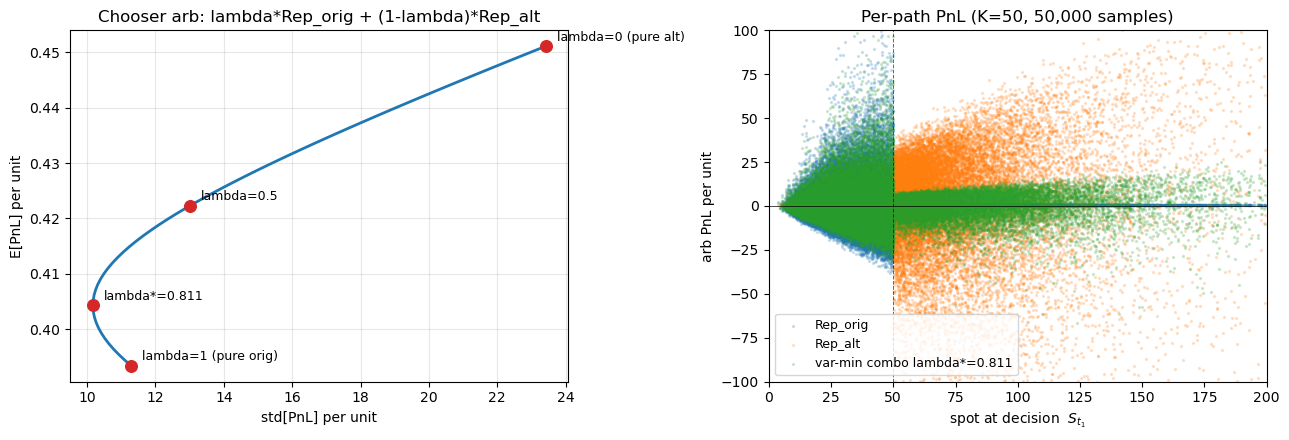

In [170]:
# --- Chooser arb: short chooser at bid, long Rubinstein replication at ask ---
# Two valid replications under r=0 (put-call parity makes them equal in t=0 value):
#   Rep_orig = Call(K, T)  + Put(K, t1)    -- residual on Case B (S_t1 <= K, ~62% of paths)
#   Rep_alt  = Put (K, T)  + Call(K, t1)   -- residual on Case A (S_t1 >  K, ~38% of paths)
# Both cost 21.80 at touch.  Chooser bid 22.20.  Net upfront credit +0.40 / unit.

K = chooser_strike
spec_C_T  = MARKET['AC_50_C']
spec_P_T  = MARKET['AC_50_P']
spec_C_t1 = MARKET['AC_50_C_2']
spec_P_t1 = MARKET['AC_50_P_2']

sT, st1 = spot_at_3w_expiry, spot_at_chooser_decision
C_T_payoff  = call_payoff(sT,  K)
P_T_payoff  = put_payoff (sT,  K)
C_t1_payoff = call_payoff(st1, K)
P_t1_payoff = put_payoff (st1, K)

rep_orig = C_T_payoff + P_t1_payoff
rep_alt  = P_T_payoff + C_t1_payoff

cost_rep_orig = spec_C_T['ask']  + spec_P_t1['ask']
cost_rep_alt  = spec_P_T['ask']  + spec_C_t1['ask']
chooser_bid   = chooser_spec['bid']

print('--- replication fairs and credits ---')
print(f"  E[rep_orig]={rep_orig.mean():.4f}  E[rep_alt]={rep_alt.mean():.4f}  "
      f"E[chooser]={chooser_payoff_per_unit.mean():.4f}")
print(f"  cost(rep_orig)={cost_rep_orig:.3f}  cost(rep_alt)={cost_rep_alt:.3f}  "
      f"chooser_bid={chooser_bid:.3f}")
print(f"  upfront credit = {chooser_bid - cost_rep_orig:+.3f} per unit")

arb_orig = (rep_orig - cost_rep_orig) + (chooser_bid - chooser_payoff_per_unit)
arb_alt  = (rep_alt  - cost_rep_alt ) + (chooser_bid - chooser_payoff_per_unit)

res_orig = rep_orig - chooser_payoff_per_unit
res_alt  = rep_alt  - chooser_payoff_per_unit
E_res2_orig = (res_orig**2).mean()
E_res2_alt  = (res_alt **2).mean()
lam_star = E_res2_alt / (E_res2_orig + E_res2_alt)
print(f"\n  E[res^2|orig]={E_res2_orig:.4f}  E[res^2|alt]={E_res2_alt:.4f}  "
      f"=> lambda*={lam_star:.4f}\n")

def combo_pnl(lam):
    rep_combo = lam * rep_orig + (1 - lam) * rep_alt
    cost      = lam * cost_rep_orig + (1 - lam) * cost_rep_alt
    return (rep_combo - cost) + (chooser_bid - chooser_payoff_per_unit)

arb_lam = combo_pnl(lam_star)
arb_50  = combo_pnl(0.5)

print(f'{"strategy":40s} {"E[PnL]":>10s} {"std":>10s} {"sharpe":>8s}')
for name, x in [('Rep_orig: Call(T)+Put(t1)              ', arb_orig),
                ('Rep_alt:  Put(T)+Call(t1)              ', arb_alt),
                ('50/50 combo                            ', arb_50),
                (f'var-min combo (lambda*={lam_star:.3f})      ', arb_lam)]:
    E, s = x.mean(), x.std(ddof=1)
    sh = E/s if s > 0 else 0
    print(f'  {name} {E:>+10.4f} {s:>10.4f} {sh:>+8.4f}')

# Volume / cap accounting (each 50-strike vanilla cap=50, chooser cap=50)
print('\n--- per chooser short, vanilla legs needed ---')
print(f"{'strategy':40s} {'C_T':>8s} {'P_T':>8s} {'C_t1':>8s} {'P_t1':>8s}  {'max_co':>10s}")
configs = [
    ('Rep_orig: Call(T)+Put(t1)',     (1.0, 0.0, 0.0, 1.0)),
    ('Rep_alt:  Put(T)+Call(t1)',     (0.0, 1.0, 1.0, 0.0)),
    ('50/50 combo',                   (0.5, 0.5, 0.5, 0.5)),
    (f'var-min combo lambda*={lam_star:.3f}',
                                      (lam_star, 1-lam_star, 1-lam_star, lam_star)),
]
for name, (a, b, c, d) in configs:
    binding = [50.0 / q for q in (a, b, c, d) if q > 1e-9]
    chooser_max = min([50.0] + binding)
    print(f'  {name:38s} {50*a:>8.2f} {50*b:>8.2f} {50*c:>8.2f} {50*d:>8.2f}  '
          f'{chooser_max:>10.2f}')

print('\n--- sizing at N_chooser_short=50, * 3000 multiplier ---')
N_co = 50
print(f'{"strategy":40s} {"E[PnL]":>14s} {"std[PnL]":>14s} {"sharpe":>8s}  {"5% worst":>14s}')
for name, x in [('Rep_orig: Call(T)+Put(t1)              ', arb_orig),
                ('Rep_alt:  Put(T)+Call(t1)              ', arb_alt),
                ('50/50 combo                            ', arb_50),
                (f'var-min combo (lambda*={lam_star:.3f})      ', arb_lam)]:
    scale = 3000 * N_co
    E, std = scale * x.mean(), scale * x.std(ddof=1)
    sh = E/std if std > 0 else 0
    p5 = scale * np.percentile(x, 5)
    print(f'  {name} {E:>+14,.0f} {std:>14,.0f} {sh:>+8.4f}  {p5:>+14,.0f}')

# Frontier + scatter
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
lams = np.linspace(0, 1, 60)
Es = np.array([combo_pnl(l).mean() for l in lams])
ss = np.array([combo_pnl(l).std(ddof=1) for l in lams])
ax.plot(ss, Es, lw=2, color='C0')
for lam, lbl in [(0, 'lambda=0 (pure alt)'),
                 (lam_star, f'lambda*={lam_star:.3f}'),
                 (0.5, 'lambda=0.5'),
                 (1, 'lambda=1 (pure orig)')]:
    p = combo_pnl(lam)
    ax.scatter(p.std(ddof=1), p.mean(), s=70, zorder=5, color='C3')
    ax.annotate(lbl, (p.std(ddof=1), p.mean()), textcoords='offset points',
                xytext=(8, 4), fontsize=9)
ax.set(xlabel='std[PnL] per unit', ylabel='E[PnL] per unit',
       title='Chooser arb: lambda*Rep_orig + (1-lambda)*Rep_alt')
ax.grid(alpha=0.3)

ax = axes[1]
N_plot = 50_000
idx = np.random.default_rng(2).choice(len(arb_orig), N_plot, replace=False)
ax.scatter(spot_at_chooser_decision[idx], arb_orig[idx], s=2, alpha=0.18, color='C0', label='Rep_orig')
ax.scatter(spot_at_chooser_decision[idx], arb_alt[idx],  s=2, alpha=0.18, color='C1', label='Rep_alt')
ax.scatter(spot_at_chooser_decision[idx], arb_lam[idx],  s=2, alpha=0.18, color='C2',
           label=f'var-min combo lambda*={lam_star:.3f}')
ax.axvline(K, color='k', ls='--', lw=0.7, alpha=0.6)
ax.axhline(0, color='k', lw=0.5)
ax.set(xlabel='spot at decision  $S_{t_1}$', ylabel='arb PnL per unit',
       title=f'Per-path PnL (K={K}, {N_plot:,} samples)',
       xlim=(0, 200), ylim=(-100, 100))
ax.legend(loc='lower left', fontsize=9)
plt.tight_layout(); plt.show()


**Read these:**

*Left plot:* the chooser payoff sits ON the vanilla call curve for the blue dots and ON the vanilla put curve for the red dots — but at any single $S_T$, *both* colors can show up. Same expiry spot, different payoff. The hockey-stick-pair of vanilla intuition is replaced by an envelope.

*Right plot:* the colors split cleanly at $S_{t_1}=K$. Above $K$ the holder commits to the call branch; below, to the put branch. After $t_1$ the chooser is locked into one vanilla and rides $S_T$ from there. That's why each color shows its own scatter pattern — the spread within a color comes from $S_T$ moving freely between $t_1$ and $T$.

**Replication advisor mentioned (Rubinstein, $r=0$):**

$$\text{Chooser}(K, t_1, T) = \text{Call}(K, T) + \text{Put}(K, t_1)$$

Two listed legs match exactly: `AC_50_C` (call, 21d) + `AC_50_P_2` (put, 14d). This identity holds in **time-0 value**, not in path-by-path terminal payoff. Per-path differences cancel in expectation but not pointwise — keep that in mind when sizing the trade.

## Summary table — what new axis each exotic introduces

In [171]:
from textwrap import dedent
print(dedent('''
    Contract              State that determines payoff           Vanilla equivalent state
    --------------------  -------------------------------------  ------------------------
    Vanilla call/put      S_T                                    S_T (baseline)
    Binary put            S_T                                    S_T (still 1D, but step)
    Knock-out put         (S_T, min_t S_t)                       S_T  -> NEW AXIS: min S
    Chooser option        (S_T, S_t1)                            S_T  -> NEW AXIS: S_t1

    Trading takeaway:
      Wherever an exotic introduces a new state axis, vanilla replication is
      imperfect.  The advisor wants us to hedge the new axis with the listed
      vanillas.  Next notebook: build those replication portfolios and look at
      the residual exposure (the part the vanillas can't see).
''').strip())

Contract              State that determines payoff           Vanilla equivalent state
--------------------  -------------------------------------  ------------------------
Vanilla call/put      S_T                                    S_T (baseline)
Binary put            S_T                                    S_T (still 1D, but step)
Knock-out put         (S_T, min_t S_t)                       S_T  -> NEW AXIS: min S
Chooser option        (S_T, S_t1)                            S_T  -> NEW AXIS: S_t1

Trading takeaway:
  Wherever an exotic introduces a new state axis, vanilla replication is
  imperfect.  The advisor wants us to hedge the new axis with the listed
  vanillas.  Next notebook: build those replication portfolios and look at
  the residual exposure (the part the vanillas can't see).


## Combined position dashboard

Total PnL of the planned position vs. spot at expiry, with chooser-case overlay.

Position below is the corrected sketch:
- Binary-put arb (canonical, x=1):  long 46 P(45), short 46 P(35), short 50 BP
- Chooser arb (var-min combo, y=1):  long 41 C, long 9 P, long 9 C_2, long 41 P_2, short 50 chooser

Edit the `positions` dict to test variants.

name            qty    entry  E[payoff]         E[PnL]       std[PnL]
AC_50_P          12   12.050     14.161        +76,003        504,012
AC_50_C          14   12.050     14.046        +83,832      1,403,447
AC_35_P         -35    4.330      5.874       -162,123        870,736
AC_45_P          50    9.100     11.084       +297,581      1,822,991
AC_50_P_2         9    9.750     11.636        +50,918        332,745
AC_50_C_2         5    9.750     11.578        +27,425        374,175
AC_50_CO        -14   22.200     25.688       -146,514      1,320,528
AC_40_BP        -50    5.000      5.225        -33,714        749,242

Total PnL per path:  E=+193,407   std=586,592   sharpe=+0.3297
Score-level (avg of 100 paths):  E=+193,407   std=58,659   sharpe=+3.2971
5% worst per path: -552,943    95%: +1,227,012


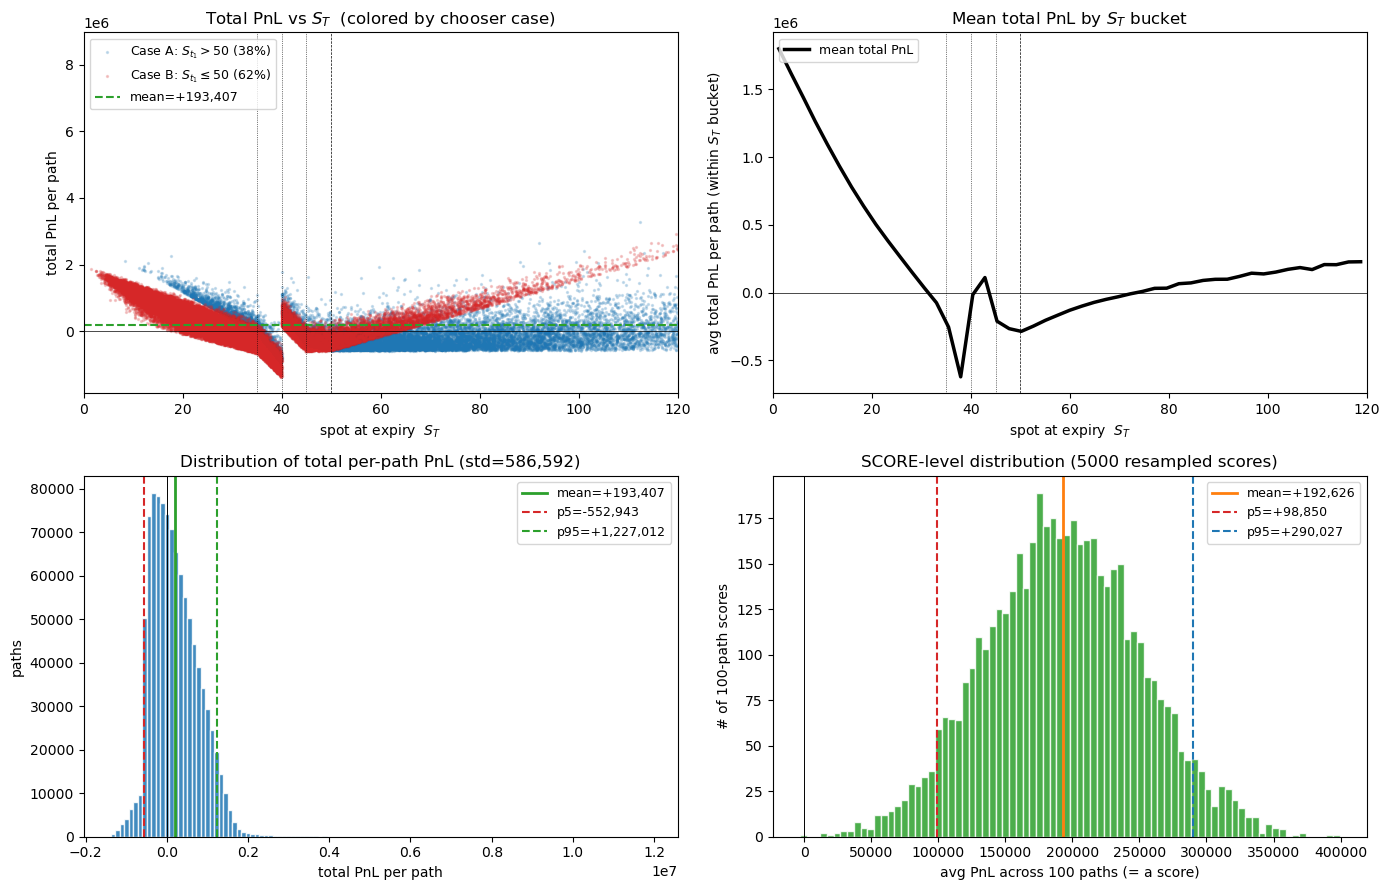

In [181]:
positions = {
    'AC_50_P':   +12,
    'AC_50_C':   +14,
    'AC_35_P':   -35,
    'AC_45_P':   +50,
    'AC_50_P_2':    +9,
    'AC_50_C_2':    +5,
    'AC_50_CO':   -14,
    'AC_40_BP':   -50,
}


CONTRACT_SIZE = 3000

# Per-leg per-path payoff helpers (using already-simulated `paths`)
def leg_payoff(name):
    spec = MARKET[name]
    if spec['kind'] == 'call':
        return call_payoff(paths[:, spec['expiry_tick']], spec['strike'])
    if spec['kind'] == 'put':
        return put_payoff (paths[:, spec['expiry_tick']], spec['strike'])
    if spec['kind'] == 'binary_put':
        return binary_put_payoff(paths[:, spec['expiry_tick']],
                                 spec['strike'], amount=spec['binary_put_payout'])
    if spec['kind'] == 'ko_put':
        return knockout_put_payoff(paths, K=spec['strike'], barrier=spec['barrier'])
    if spec['kind'] == 'underlying':
        return paths[:, spec['expiry_tick']]
    if spec['kind'] == 'chooser':
        return chooser_payoff(paths, spec['strike'],
                              t1_step=spec['decision_tick'], T_step=spec['expiry_tick'])
    raise ValueError(spec['kind'])

# Build per-path PnL = sum over legs of qty * size * (payoff - entry_price)
total_pnl = np.zeros(len(spot_at_3w_expiry))
print(f"{'name':12s} {'qty':>6s} {'entry':>8s} {'E[payoff]':>10s} {'E[PnL]':>14s} {'std[PnL]':>14s}")
for name, qty in positions.items():
    if qty == 0:
        continue
    spec = MARKET[name]
    payoff = leg_payoff(name)
    entry  = spec['ask'] if qty > 0 else spec['bid']
    leg_pnl = qty * CONTRACT_SIZE * (payoff - entry)
    total_pnl += leg_pnl
    print(f'{name:12s} {qty:>6d} {entry:>8.3f} {payoff.mean():>10.3f} '
          f'{leg_pnl.mean():>+14,.0f} {leg_pnl.std(ddof=1):>14,.0f}')

# Stats
mean_total = total_pnl.mean()
std_total  = total_pnl.std(ddof=1)
score_std  = std_total / np.sqrt(100)         # CLT: avg of 100 paths
print()
print(f'Total PnL per path:  E={mean_total:+,.0f}   std={std_total:,.0f}   sharpe={mean_total/std_total:+.4f}')
print(f'Score-level (avg of 100 paths):  E={mean_total:+,.0f}   std={score_std:,.0f}   '
      f'sharpe={mean_total/score_std:+.4f}')
print(f'5% worst per path: {np.percentile(total_pnl, 5):+,.0f}    '
      f'95%: {np.percentile(total_pnl, 95):+,.0f}')

# Chooser-case overlay (S_t1 vs K=50 for the chooser)
case_A = spot_at_chooser_decision >  50.0   # chooser holder picks call
case_B = spot_at_chooser_decision <= 50.0   # chooser holder picks put

# --- Plots ---
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1) total PnL vs S_T, colored by chooser case
ax = axes[0, 0]
N_plot = 50_000
idx = np.random.default_rng(3).choice(len(total_pnl), N_plot, replace=False)
mA, mB = case_A[idx], case_B[idx]
ax.scatter(spot_at_3w_expiry[idx][mA], total_pnl[idx][mA], s=2, alpha=0.20, color='C0',
           label=f'Case A: $S_{{t_1}}>50$ ({case_A.mean():.0%})')
ax.scatter(spot_at_3w_expiry[idx][mB], total_pnl[idx][mB], s=2, alpha=0.20, color='C3',
           label=f'Case B: $S_{{t_1}}\\leq 50$ ({case_B.mean():.0%})')
ax.axhline(0, color='k', lw=0.5)
ax.axhline(mean_total, color='C2', ls='--', lw=1.5, label=f'mean={mean_total:+,.0f}')
ax.axvline(35, color='k', ls=':', lw=0.5)
ax.axvline(40, color='k', ls=':', lw=0.5)
ax.axvline(45, color='k', ls=':', lw=0.5)
ax.axvline(50, color='k', ls='--', lw=0.5)
ax.set(xlabel='spot at expiry  $S_T$', ylabel='total PnL per path',
       title='Total PnL vs $S_T$  (colored by chooser case)',
       xlim=(0, 120))
ax.legend(loc='upper left', fontsize=9)

# 2) Mean total PnL per S_T bucket
ax = axes[0, 1]
bin_edges = np.linspace(0, 120, 50)
bin_mid = 0.5*(bin_edges[:-1] + bin_edges[1:])
which = np.digitize(spot_at_3w_expiry, bin_edges) - 1
mean_total_per_bucket = np.array([
    total_pnl[which == i].mean() if (which == i).any() else 0
    for i in range(len(bin_mid))
])
ax.plot(bin_mid, mean_total_per_bucket, lw=2.5, color='k', label='mean total PnL')
ax.axhline(0, color='k', lw=0.5)
ax.axvline(35, color='k', ls=':', lw=0.5); ax.axvline(40, color='k', ls=':', lw=0.5)
ax.axvline(45, color='k', ls=':', lw=0.5); ax.axvline(50, color='k', ls='--', lw=0.5)
ax.set(xlabel='spot at expiry  $S_T$', ylabel='avg total PnL per path (within $S_T$ bucket)',
       title='Mean total PnL by $S_T$ bucket',
       xlim=(0, 120))
ax.legend(loc='upper left', fontsize=9)

# 3) Histogram of total PnL
ax = axes[1, 0]
ax.hist(total_pnl, bins=120, alpha=0.85, color='C0', edgecolor='white')
ax.axvline(0, color='k', lw=0.7)
ax.axvline(mean_total,                             color='C2', lw=2,   label=f'mean={mean_total:+,.0f}')
ax.axvline(np.percentile(total_pnl, 5),            color='C3', ls='--',label=f'p5={np.percentile(total_pnl,5):+,.0f}')
ax.axvline(np.percentile(total_pnl, 95),           color='C2', ls='--',label=f'p95={np.percentile(total_pnl,95):+,.0f}')
ax.set(xlabel='total PnL per path', ylabel='paths',
       title=f'Distribution of total per-path PnL (std={std_total:,.0f})')
ax.legend(fontsize=9)

# 4) Score-level distribution by simulating 100-path means
rng_score = np.random.default_rng(5)
N_score = 5000
score_means = np.array([
    total_pnl[rng_score.choice(len(total_pnl), 100, replace=False)].mean()
    for _ in range(N_score)
])
ax = axes[1, 1]
ax.hist(score_means, bins=80, alpha=0.85, color='C2', edgecolor='white')
ax.axvline(0, color='k', lw=0.7)
ax.axvline(score_means.mean(), color='C1', lw=2,
           label=f'mean={score_means.mean():+,.0f}')
ax.axvline(np.percentile(score_means, 5), color='C3', ls='--',
           label=f'p5={np.percentile(score_means,5):+,.0f}')
ax.axvline(np.percentile(score_means, 95), color='C0', ls='--',
           label=f'p95={np.percentile(score_means,95):+,.0f}')
ax.set(xlabel='avg PnL across 100 paths (= a score)', ylabel='# of 100-path scores',
       title=f'SCORE-level distribution ({N_score} resampled scores)')
ax.legend(fontsize=9)

plt.tight_layout(); plt.show()


## Quadratic optimization — Markowitz frontier

Solve `max E[PnL] − ½ λ · Var[PnL]` over signed quantities for every listed contract,
subject to `|q_i| ≤ cap_i`.  Sweep λ to trace the efficient frontier; pick a point.

Larger λ → lower variance, lower EV.  Use the integer-rounded position from the row
you like and paste into `simulation.py` or the dashboard cell.

In [ ]:
# --- Quadratic optimization for the full portfolio ---
# Decision variable: signed quantity per instrument (no long/short split; bid-ask half-spread
# slippage on sign flip ignored, ~0.5% of fair, irrelevant for variance).
# Solve:  max  E[PnL] - 0.5 * lam * Var[PnL]   s.t.  |q_i| <= cap_i
# Sweep lam, print frontier with integer-rounded positions.

from scipy.optimize import minimize

# Per-path payoff matrix: column i = payoff_i(path) per 1 long contract
INSTR_QP = [
    ('AC_50_P',   50),  ('AC_50_C',  50),  ('AC_35_P',  50),  ('AC_40_P',  50),
    ('AC_45_P',   50),  ('AC_60_C',  50),  ('AC_50_P_2',50),  ('AC_50_C_2',50),
    ('AC_50_CO',  50),  ('AC_40_BP', 50),  ('AC_45_KO', 500), ('AC',       200),
]
qp_names = [n for n, _ in INSTR_QP]
qp_caps  = np.array([c for _, c in INSTR_QP], dtype=float)
SIZE_QP  = 3000

# Per-path PnL of long-1-contract for each instrument (entered at ASK, our worst-side price)
def _qp_per_unit(name):
    spec = MARKET[name]
    if spec['kind'] == 'call':       p = call_payoff(paths[:, spec['expiry_tick']], spec['strike'])
    elif spec['kind'] == 'put':      p = put_payoff (paths[:, spec['expiry_tick']], spec['strike'])
    elif spec['kind'] == 'binary_put':
        p = binary_put_payoff(paths[:, spec['expiry_tick']], spec['strike'],
                              amount=spec['binary_put_payout'])
    elif spec['kind'] == 'ko_put':
        p = knockout_put_payoff(paths, K=spec['strike'], barrier=spec['barrier'])
    elif spec['kind'] == 'chooser':
        p = chooser_payoff(paths, spec['strike'],
                           t1_step=spec['decision_tick'], T_step=spec['expiry_tick'])
    elif spec['kind'] == 'underlying':
        p = paths[:, spec['expiry_tick']]
    return SIZE_QP * (p - spec['ask'])             # long-side per-unit PnL

X_qp = np.column_stack([_qp_per_unit(n) for n in qp_names])      # (n_paths, n_instr)

def qp_eval(q):
    pnl = X_qp @ q
    return pnl.mean(), pnl.std(ddof=1), pnl

def qp_solve(lam):
    """max E - 0.5*lam*Var  s.t.  |q_i| <= cap_i.  Returns continuous q."""
    def neg_obj(q):
        pnl = X_qp @ q
        return -(pnl.mean() - 0.5 * lam * pnl.var(ddof=1))
    bounds = [(-c, c) for c in qp_caps]
    res = minimize(neg_obj, np.zeros(len(qp_names)),
                   bounds=bounds, method='L-BFGS-B',
                   options={'ftol': 1e-12, 'maxiter': 2000})
    return res.x

# --- Frontier sweep ---
print(f'{"lambda":>10s}  {"E[PnL]":>14s}  {"std":>14s}  {"per-path Sharpe":>16s}  {"score Sharpe":>14s}')
results = []
for lam in [1e-9, 1e-8, 1e-7, 5e-7, 1e-6, 2e-6, 5e-6, 1e-5, 1e-4]:
    q = qp_solve(lam)
    E, std, _ = qp_eval(q)
    sh_path  = E/std if std > 0 else 0
    sh_score = sh_path * np.sqrt(100)               # score = average of 100 paths
    results.append((lam, q, E, std, sh_path))
    print(f'{lam:>10.2e}  {E:>+14,.0f}  {std:>14,.0f}  {sh_path:>+16.4f}  {sh_score:>+14.2f}')

# --- Pick a row by index and emit a positions dict ---
PICK_LAM = 5e-7    # change this to choose a different frontier point
q_pick   = qp_solve(PICK_LAM)
q_int    = np.array([int(round(qi)) for qi in q_pick])

# Re-evaluate at integer-rounded position
E_int, std_int, _ = qp_eval(q_int)
print(f'\n=== chosen lambda = {PICK_LAM:.0e}: integer-rounded position ===')
print(f'E={E_int:+,.0f}  std={std_int:,.0f}  per-path Sharpe={E_int/std_int:+.4f}  '
      f'score Sharpe={E_int/std_int*10:+.2f}')
print('positions = {')
for n, qi in zip(qp_names, q_int):
    print(f'    "{n}": {qi:+d},')
print('}')